In [20]:
import pandas as pd

FILE_PATH = r"D:\Project-Electricity-Demand-Forecasting\processed_data\daily_electricity_dataset.csv"

df = pd.read_csv(FILE_PATH)

target = "Usage_kWh"

# Search original House names containing 10, 54 or 57
check = df[
    df["House"].astype(str).str.contains(
        r"House(?:_|#)?(?:10|54|57)(?:_|$)",
        case=False,
        regex=True,
        na=False
    )
].copy()

print("=" * 70)
print("SOURCE VERIFICATION: HOUSES 10, 54, 57")
print("=" * 70)

print("\nHouse names found:")
print(check["House"].value_counts().to_string())

print("\nCity values:")
print(check["City"].value_counts().to_string())

print("\nTarget statistics:")
print(check[target].describe())

print("\nMissing target by House:")
print(
    check.groupby("House")[target]
    .agg(
        Total_Rows="size",
        Missing_Target=lambda x: x.isna().sum(),
        Valid_Target=lambda x: x.notna().sum()
    )
    .to_string()
)

print("\nValid target examples:")
print(
    check[check[target].notna()]
    [["date", "City", "House", target]]
    .head(20)
    .to_string(index=False)
)

SOURCE VERIFICATION: HOUSES 10, 54, 57

House names found:
House
skardu_House57       499
skardu_House54       366
lahore_House10       341
skardu_House57_11     48
skardu_House57_13     36
skardu_House57_12     36
skardu_House57_10     36
skardu_House57_09     36
skardu_House54_06     36
skardu_House57_06     36
skardu_House57_05     36
skardu_House57_03     36
skardu_House57_02     36
skardu_House57_01     36
skardu_House54_10     36
skardu_House54_09     36
skardu_House57_07     36
skardu_House54_07     36
skardu_House54_05     36
lahore_House10_06     36
skardu_House54_03     36
skardu_House54_02     36
lahore_House10_02     36
lahore_House10_03     36
lahore_House10_09     36
lahore_House10_05     36
lahore_House10_07     36
lahore_House10_01     35
lahore_House10_04     35
skardu_House57_08     35
lahore_House10_08     35
skardu_House54_04     35
skardu_House57_04     35
skardu_House54_01     35
skardu_House54_08     35
skardu_House57_14     34
lahore_House10_10     29
skardu_Hou

In [21]:
import pandas as pd

INPUT_FILE = r"D:\Project-Electricity-Demand-Forecasting\processed_data\clean_daily_electricity.csv"

OUTPUT_FILE = r"D:\Project-Electricity-Demand-Forecasting\processed_data\final_daily_electricity.csv"

TARGET = "Electricity_Consumption_kWh"


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv(INPUT_FILE)

df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("=" * 70)
print("FINAL DAILY ELECTRICITY DATASET")
print("=" * 70)

print("Original shape:", df.shape)


# ============================================================
# 2. REMOVE HOUSES WITH 100% MISSING TARGET
# ============================================================

excluded_houses = [
    "House#10",
    "House#54",
    "House#57"
]

before = len(df)

df = df[~df["House"].isin(excluded_houses)].copy()

print("\nExcluded houses:")
print(excluded_houses)

print("Rows removed:", before - len(df))


# ============================================================
# 3. REMOVE ROWS WITH MISSING TARGET
# ============================================================

before = len(df)

df = df[df[TARGET].notna()].copy()

print("\nRows with missing target removed:", before - len(df))


# ============================================================
# 4. KEEP ONLY REQUIRED COLUMNS
# ============================================================

df = df[
    [
        "date",
        "City",
        "House",
        "House_Number",
        TARGET
    ]
].copy()


# ============================================================
# 5. SORT DATA
# ============================================================

df = df.sort_values(
    ["House_Number", "date"]
).reset_index(drop=True)


# ============================================================
# 6. BASIC VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL VALIDATION")
print("=" * 70)

print("\nFinal shape:", df.shape)

print("\nUnique houses:", df["House"].nunique())

print("\nUnique cities:", df["City"].nunique())

print("\nDate range:")
print("Minimum:", df["date"].min())
print("Maximum:", df["date"].max())


# ============================================================
# 7. DUPLICATE CHECK
# ============================================================

duplicate_count = df.duplicated(
    subset=["House", "date"]
).sum()

print("\nDuplicate House + Date:", duplicate_count)


# ============================================================
# 8. MISSING VALUES
# ============================================================

print("\nMissing values:")
print(df.isna().sum())


# ============================================================
# 9. TARGET CHECK
# ============================================================

print("\nTarget statistics:")
print(df[TARGET].describe())


# ============================================================
# 10. CITY DISTRIBUTION
# ============================================================

print("\nRows by city:")
print(df["City"].value_counts().sort_index())


# ============================================================
# 11. HOUSE DISTRIBUTION
# ============================================================

print("\nRows by house:")

house_counts = (
    df.groupby(["City", "House"])
    .size()
    .reset_index(name="Rows")
)

print(house_counts.to_string(index=False))


# ============================================================
# 12. CHECK EXCLUDED HOUSES
# ============================================================

print("\nExcluded houses still present:")

print(
    df[df["House"].isin(excluded_houses)]
    ["House"]
    .unique()
)


# ============================================================
# 13. SAVE
# ============================================================

df.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\n" + "=" * 70)
print("SAVED SUCCESSFULLY")
print("=" * 70)

print(OUTPUT_FILE)

FINAL DAILY ELECTRICITY DATASET
Original shape: (21497, 5)

Excluded houses:
['House#10', 'House#54', 'House#57']
Rows removed: 1206

Rows with missing target removed: 444

FINAL VALIDATION

Final shape: (19847, 5)

Unique houses: 56

Unique cities: 6

Date range:
Minimum: 2023-07-16 00:00:00
Maximum: 2024-11-28 00:00:00

Duplicate House + Date: 0

Missing values:
date                           0
City                           0
House                          0
House_Number                   0
Electricity_Consumption_kWh    0
dtype: int64

Target statistics:
count    19847.000000
mean        16.212515
std         16.767088
min          0.000000
25%          4.734863
50%         11.112445
75%         22.413062
max        167.470849
Name: Electricity_Consumption_kWh, dtype: float64

Rows by city:
City
Islamabad    3468
Karachi      3632
Lahore       3188
Multan       3616
Peshawar     3490
Skardu       2453
Name: count, dtype: int64

Rows by house:
     City    House  Rows
Islamabad Hous

In [2]:
import pandas as pd

file_path = r"D:\Project-Electricity-Demand-Forecasting\metadata_ultimate.xlsx"

metadata = pd.read_excel(file_path)

print("Shape:", metadata.shape)

print("\nColumns:")
print(metadata.columns.tolist())

print("\nFirst 5 rows:")
print(metadata.head())

print("\nData Types:")
print(metadata.dtypes)

print("\nMissing Values:")
print(metadata.isnull().sum())

print("\nUnique Values:")
for col in metadata.columns:
    print(f"\n{col}:")
    print(metadata[col].unique()[:20])

Shape: (59, 46)

Columns:
['House', 'City', 'Owner/Rented', 'No. of people (Temp+Perm)', 'No. of Permanent residents', 'No. of Children (0-13)', 'No. of Adults (14-60)', 'No. of Seniors\n(above 60)', 'No. of temporary residents', 'Property Area (Marla)', 'Covered Area', 'No of Floors', 'Floor of Residency', 'Build year of house', 'Wapda Connection type', 'Average Ceiling Height ft', 'Ceiling Type', 'Roof Type', 'Flooring Type', 'Interior Wall', 'Exterior Wall', 'No. of rooms', 'Room Dimensions', 'Kitchen', 'Number of Washrooms', 'Number of Stores', 'Doors Type', 'Air Conditioners', 'Air Coolers', 'Refrigerators', 'Washing Machines ', 'LED Bulbs', 'Tube Lights', 'Celling Fans', 'Wall Fans', 'Stand Fans', 'Water Dispensers', 'Water Pumps', 'Electric Cooker', 'Electric heaters', 'Electric Irons', 'Sewing Machine', 'Microwave Ovens', 'Geysers', 'UPS ', 'Other Electronic Devices']

First 5 rows:
     House    City Owner/Rented  No. of people (Temp+Perm)  \
0  House#1  Lahore        Owner   

In [3]:
# clean meta data
metadata.columns = (
    metadata.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [4]:
# check for duplicates
print("Unique houses:", metadata["house"].nunique())

print("\nDuplicate house records:")
print(metadata[metadata.duplicated("house", keep=False)])

Unique houses: 59

Duplicate house records:
Empty DataFrame
Columns: [house, city, owner/rented, no._of_people_(temp+perm), no._of_permanent_residents, no._of_children_(0-13), no._of_adults_(14-60), no._of_seniors
(above_60), no._of_temporary_residents, property_area_(marla), covered_area, no_of_floors, floor_of_residency, build_year_of_house, wapda_connection_type, average_ceiling_height_ft, ceiling_type, roof_type, flooring_type, interior_wall, exterior_wall, no._of_rooms, room_dimensions, kitchen, number_of_washrooms, number_of_stores, doors_type, air_conditioners, air_coolers, refrigerators, washing_machines, led_bulbs, tube_lights, celling_fans, wall_fans, stand_fans, water_dispensers, water_pumps, electric_cooker, electric_heaters, electric_irons, sewing_machine, microwave_ovens, geysers, ups, other_electronic_devices]
Index: []

[0 rows x 46 columns]


In [5]:
#check city
print(metadata["city"].value_counts())

city
Lahore       10
Multan       10
Peshawar     10
Karachi      10
Islamabad    10
Skardu        9
Name: count, dtype: int64


In [9]:
import pandas as pd
import numpy as np

# ============================================================
# 1. LOAD METADATA
# ============================================================

file_path = r'D:\Project-Electricity-Demand-Forecasting\metadata_ultimate.xlsx'

metadata = pd.read_excel(file_path)

print("Original shape:", metadata.shape)


# ============================================================
# 2. CLEAN COLUMN NAMES
# ============================================================

metadata.columns = (
    metadata.columns
    .str.strip()
    .str.replace("\n", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
)

print("\nCleaned columns:")
print(metadata.columns.tolist())


# ============================================================
# 3. STANDARDIZE COLUMN NAMES
# ============================================================

rename_columns = {
    "No. of people (Temp+Perm)": "Total_People",
    "No. of Permanent residents": "Permanent_Residents",
    "No. of Children (0-13)": "Children",
    "No. of Adults (14-60)": "Adults",
    "No. of Seniors (above 60)": "Seniors",
    "No. of temporary residents": "Temporary_Residents",

    "Property Area (Marla)": "Property_Area_Marla",
    "Covered Area": "Covered_Area",
    "No of Floors": "No_of_Floors",
    "Floor of Residency": "Floor_of_Residency",
    "Build year of house": "Build_Year",

    "Wapda Connection type": "Wapda_Connection_Type",
    "Average Ceiling Height ft": "Ceiling_Height_ft",

    "Ceiling Type": "Ceiling_Type",
    "Roof Type": "Roof_Type",
    "Flooring Type": "Flooring_Type",
    "Interior Wall": "Interior_Wall",
    "Exterior Wall": "Exterior_Wall",

    "No. of rooms": "No_of_Rooms",
    "Room Dimensions": "Room_Dimensions",
    "Number of Washrooms": "Number_of_Washrooms",
    "Number of Stores": "Number_of_Stores",

    "Doors Type": "Doors_Type",

    "Air Conditioners": "Air_Conditioners",
    "Air Coolers": "Air_Coolers",
    "Refrigerators": "Refrigerators",
    "Washing Machines": "Washing_Machines",

    "LED Bulbs": "LED_Bulbs",
    "Tube Lights": "Tube_Lights",

    "Celling Fans": "Ceiling_Fans",
    "Wall Fans": "Wall_Fans",
    "Stand Fans": "Stand_Fans",

    "Water Dispensers": "Water_Dispensers",
    "Water Pumps": "Water_Pumps",

    "Electric Cooker": "Electric_Cooker",
    "Electric heaters": "Electric_Heaters",
    "Electric Irons": "Electric_Irons",
    "Sewing Machine": "Sewing_Machine",
    "Microwave Ovens": "Microwave_Ovens",
    "Geysers": "Geysers",
    "UPS": "UPS",
    "Other Electronic Devices": "Other_Electronic_Devices"
}

metadata = metadata.rename(columns=rename_columns)

print("\nFinal column names:")
print(metadata.columns.tolist())


# ============================================================
# 4. STANDARDIZE HOUSE AND CITY
# ============================================================

metadata["House"] = metadata["House"].astype(str).str.strip()

metadata["City"] = (
    metadata["City"]
    .astype(str)
    .str.strip()
    .str.title()
)


# ============================================================
# 5. STANDARDIZE CATEGORICAL VALUES
# ============================================================

# Owner / rented
metadata["Owner/Rented"] = (
    metadata["Owner/Rented"]
    .astype(str)
    .str.strip()
    .str.title()
)

# WAPDA connection
metadata["Wapda_Connection_Type"] = (
    metadata["Wapda_Connection_Type"]
    .astype("string")
    .str.strip()
)

metadata["Wapda_Connection_Type"] = (
    metadata["Wapda_Connection_Type"]
    .replace({
        "3 Phase": "3 phase",
        "3 phase": "3 phase",
        "1 Phase": "1 phase",
        "1 phase": "1 phase",
        "Net Meter": "Net Meter"
    })
)


# Ceiling type
metadata["Ceiling_Type"] = (
    metadata["Ceiling_Type"]
    .astype("string")
    .str.strip()
)

metadata["Ceiling_Type"] = (
    metadata["Ceiling_Type"]
    .replace({
        "Fall Celling": "Fall Ceiling",
        "Fal Ceiling": "Fall Ceiling"
    })
)


# Flooring
metadata["Flooring_Type"] = (
    metadata["Flooring_Type"]
    .astype("string")
    .str.strip()
    .str.lower()
)


# Interior wall
metadata["Interior_Wall"] = (
    metadata["Interior_Wall"]
    .astype("string")
    .str.strip()
    .str.lower()
)


# Doors
metadata["Doors_Type"] = (
    metadata["Doors_Type"]
    .astype("string")
    .str.strip()
    .str.title()
)


# ============================================================
# 6. NUMERIC COLUMNS
# ============================================================

numeric_columns = [
    "Total_People",
    "Permanent_Residents",
    "Children",
    "Adults",
    "Seniors",
    "Temporary_Residents",
    "Property_Area_Marla",
    "Covered_Area",
    "No_of_Floors",
    "Build_Year",
    "Ceiling_Height_ft",
    "No_of_Rooms",
    "Number_of_Washrooms",
    "Number_of_Stores",
    "Air_Conditioners",
    "Air_Coolers",
    "Refrigerators",
    "Washing_Machines",
    "LED_Bulbs",
    "Tube_Lights",
    "Ceiling_Fans",
    "Wall_Fans",
    "Stand_Fans",
    "Water_Dispensers",
    "Water_Pumps",
    "Electric_Cooker",
    "Electric_Heaters",
    "Electric_Irons",
    "Sewing_Machine",
    "Microwave_Ovens",
    "Geysers",
    "UPS"
]

for col in numeric_columns:
    if col in metadata.columns:
        metadata[col] = pd.to_numeric(
            metadata[col],
            errors="coerce"
        )


# ============================================================
# 7. HANDLE "OTHER ELECTRONIC DEVICES"
# ============================================================

def clean_other_devices(value):

    if pd.isna(value):
        return 0

    value = str(value).strip()

    if value == "Massage Chair":
        return 1

    if value == "2 Massage Chairs":
        return 2

    try:
        return float(value)
    except:
        return 0


metadata["Other_Electronic_Devices"] = (
    metadata["Other_Electronic_Devices"]
    .apply(clean_other_devices)
)


# ============================================================
# 8. CHECK MISSING VALUES BEFORE IMPUTATION
# ============================================================

print("\nMissing values before handling:")

missing = metadata.isnull().sum()

print(missing[missing > 0])


# ============================================================
# 9. FILL NUMERIC MISSING VALUES
# ============================================================

# For appliance counts:
# missing usually means the appliance was not recorded.
# Because these datasets use 0 extensively, use 0 here.

appliance_columns = [
    "Air_Conditioners",
    "Air_Coolers",
    "Refrigerators",
    "Washing_Machines",
    "LED_Bulbs",
    "Tube_Lights",
    "Ceiling_Fans",
    "Wall_Fans",
    "Stand_Fans",
    "Water_Dispensers",
    "Water_Pumps",
    "Electric_Cooker",
    "Electric_Heaters",
    "Electric_Irons",
    "Sewing_Machine",
    "Microwave_Ovens",
    "Geysers",
    "UPS",
    "Other_Electronic_Devices"
]

for col in appliance_columns:
    if col in metadata.columns:
        metadata[col] = metadata[col].fillna(0)


# Other household measurements:
# use median because these are continuous/count characteristics.

household_numeric = [
    "Total_People",
    "Permanent_Residents",
    "Children",
    "Adults",
    "Seniors",
    "Temporary_Residents",
    "Property_Area_Marla",
    "Covered_Area",
    "Build_Year",
    "Ceiling_Height_ft",
    "No_of_Rooms",
    "Number_of_Washrooms",
    "Number_of_Stores"
]

for col in household_numeric:
    if col in metadata.columns:
        metadata[col] = metadata[col].fillna(
            metadata[col].median()
        )


# ============================================================
# 10. CATEGORICAL MISSING VALUES
# ============================================================

categorical_columns = [
    "Owner/Rented",
    "Wapda_Connection_Type",
    "Ceiling_Type",
    "Roof_Type",
    "Flooring_Type",
    "Interior_Wall",
    "Exterior_Wall",
    "Floor_of_Residency",
    "Room_Dimensions",
    "Doors_Type"
]

for col in categorical_columns:

    if col in metadata.columns:

        mode = metadata[col].mode()

        if len(mode) > 0:
            metadata[col] = metadata[col].fillna(mode[0])


# ============================================================
# 11. CHECK DUPLICATES
# ============================================================

print("\nDuplicate rows:", metadata.duplicated().sum())

print(
    "Duplicate House IDs:",
    metadata["House"].duplicated().sum()
)


# ============================================================
# 12. CHECK HOUSE AND CITY
# ============================================================

print("\nUnique houses:", metadata["House"].nunique())

print("\nCities:")
print(metadata["City"].value_counts())


# ============================================================
# 13. FINAL MISSING VALUE CHECK
# ============================================================

print("\nMissing values after cleaning:")

missing_after = metadata.isnull().sum()

print(missing_after[missing_after > 0])


# ============================================================
# 14. SAVE CLEAN METADATA
# ============================================================

output_path = (
    r"D:\Project-Electricity-Demand-Forecasting"
    r"\processed_data\clean_metadata.csv"
)

metadata.to_csv(output_path, index=False)

print("\n===================================")
print("CLEAN METADATA SAVED SUCCESSFULLY")
print("===================================")

print("Shape:", metadata.shape)
print("Output:", output_path)

Original shape: (59, 46)

Cleaned columns:
['House', 'City', 'Owner/Rented', 'No. of people (Temp+Perm)', 'No. of Permanent residents', 'No. of Children (0-13)', 'No. of Adults (14-60)', 'No. of Seniors (above 60)', 'No. of temporary residents', 'Property Area (Marla)', 'Covered Area', 'No of Floors', 'Floor of Residency', 'Build year of house', 'Wapda Connection type', 'Average Ceiling Height ft', 'Ceiling Type', 'Roof Type', 'Flooring Type', 'Interior Wall', 'Exterior Wall', 'No. of rooms', 'Room Dimensions', 'Kitchen', 'Number of Washrooms', 'Number of Stores', 'Doors Type', 'Air Conditioners', 'Air Coolers', 'Refrigerators', 'Washing Machines', 'LED Bulbs', 'Tube Lights', 'Celling Fans', 'Wall Fans', 'Stand Fans', 'Water Dispensers', 'Water Pumps', 'Electric Cooker', 'Electric heaters', 'Electric Irons', 'Sewing Machine', 'Microwave Ovens', 'Geysers', 'UPS', 'Other Electronic Devices']

Final column names:
['House', 'City', 'Owner/Rented', 'Total_People', 'Permanent_Residents', 'Ch

In [11]:
#STEP 2 — Process Weather Data

#Now we need to create:

#daily_weather.csv

import pandas as pd
from pathlib import Path

# ============================================================
# STEP 1: WEATHER DATA FOLDER
# ============================================================

weather_folder = Path(
    r"D:\Project-Electricity-Demand-Forecasting\weather_dataset\weather_dataset"
)

# Find all CSV files
weather_files = list(weather_folder.glob("*.csv"))

print("Weather files found:")
for file in weather_files:
    print("-", file.name)


# ============================================================
# STEP 2: PROCESS EACH CITY
# ============================================================

daily_weather_list = []

for file in weather_files:

    print(f"\nProcessing: {file.name}")

    # Read CSV
    weather = pd.read_csv(file)

    # Clean column names
    weather.columns = (
        weather.columns
        .str.strip()
        .str.replace(" ", "_")
    )

    # --------------------------------------------------------
    # Convert datetime
    # --------------------------------------------------------

    weather["datetime"] = pd.to_datetime(
        weather["datetime"],
        errors="coerce"
    )

    # Remove invalid datetime rows
    weather = weather.dropna(subset=["datetime"])

    # --------------------------------------------------------
    # Create Date
    # --------------------------------------------------------

    weather["Date"] = weather["datetime"].dt.normalize()

    # --------------------------------------------------------
    # City from filename
    # --------------------------------------------------------

    city = file.stem.strip().title()

    weather["City"] = city

    print("City:", city)
    print("Rows:", len(weather))
    print("Date range:",
          weather["Date"].min(),
          "to",
          weather["Date"].max())

    # --------------------------------------------------------
    # Convert weather columns to numeric
    # --------------------------------------------------------

    numeric_columns = [
        "Temperature",
        "Humidity",
        "Dew",
        "Precipitation",
        "Wind_Speed",
        "Wind_Direction",
        "Pressure",
        "Solar_Radiation",
        "Solar_Energy",
        "UV_Index"
    ]

    for col in numeric_columns:
        if col in weather.columns:
            weather[col] = pd.to_numeric(
                weather[col],
                errors="coerce"
            )

    # --------------------------------------------------------
    # Daily aggregation
    # --------------------------------------------------------

    aggregation = {}

    if "Temperature" in weather.columns:
        aggregation["Temperature"] = "mean"

    if "Humidity" in weather.columns:
        aggregation["Humidity"] = "mean"

    if "Dew" in weather.columns:
        aggregation["Dew"] = "mean"

    if "Precipitation" in weather.columns:
        aggregation["Precipitation"] = "sum"

    if "Wind_Speed" in weather.columns:
        aggregation["Wind_Speed"] = "mean"

    if "Wind_Direction" in weather.columns:
        aggregation["Wind_Direction"] = "mean"

    if "Pressure" in weather.columns:
        aggregation["Pressure"] = "mean"

    if "Solar_Radiation" in weather.columns:
        aggregation["Solar_Radiation"] = "mean"

    if "Solar_Energy" in weather.columns:
        aggregation["Solar_Energy"] = "sum"

    if "UV_Index" in weather.columns:
        aggregation["UV_Index"] = "mean"

    daily = (
        weather
        .groupby(["City", "Date"], as_index=False)
        .agg(aggregation)
    )

    daily_weather_list.append(daily)


# ============================================================
# STEP 3: COMBINE ALL CITIES
# ============================================================

daily_weather = pd.concat(
    daily_weather_list,
    ignore_index=True
)


# ============================================================
# STEP 4: SORT
# ============================================================

daily_weather = daily_weather.sort_values(
    ["City", "Date"]
).reset_index(drop=True)


# ============================================================
# STEP 5: CHECK DUPLICATES
# ============================================================

duplicates = daily_weather.duplicated(
    subset=["City", "Date"]
).sum()

print("\nDuplicate City + Date rows:", duplicates)


# ============================================================
# STEP 6: CHECK MISSING VALUES
# ============================================================

print("\nMissing values:")
print(daily_weather.isnull().sum())


# ============================================================
# STEP 7: CHECK CITY COVERAGE
# ============================================================

print("\nCity counts:")
print(daily_weather["City"].value_counts())


# ============================================================
# STEP 8: CHECK FINAL DATASET
# ============================================================

print("\nFinal shape:", daily_weather.shape)

print("\nFirst 10 rows:")
print(daily_weather.head(10))


# ============================================================
# STEP 9: SAVE
# ============================================================

output_path = Path(
    r"D:\Project-Electricity-Demand-Forecasting\processed_data\daily_weather.csv"
)

daily_weather.to_csv(
    output_path,
    index=False
)

print("\nSaved successfully:")
print(output_path)

Weather files found:
- Islamabad.csv
- Karachi.csv
- Lahore.csv
- Multan.csv
- Peshawar.csv
- Skardu.csv

Processing: Islamabad.csv
City: Islamabad
Rows: 519
Date range: 2023-07-01 00:00:00 to 2024-11-30 00:00:00

Processing: Karachi.csv
City: Karachi
Rows: 519
Date range: 2023-07-01 00:00:00 to 2024-11-30 00:00:00

Processing: Lahore.csv
City: Lahore
Rows: 519
Date range: 2023-07-01 00:00:00 to 2024-11-30 00:00:00

Processing: Multan.csv
City: Multan
Rows: 519
Date range: 2023-07-01 00:00:00 to 2024-11-30 00:00:00

Processing: Peshawar.csv
City: Peshawar
Rows: 519
Date range: 2023-07-01 00:00:00 to 2024-11-30 00:00:00

Processing: Skardu.csv
City: Skardu
Rows: 519
Date range: 2023-07-01 00:00:00 to 2024-11-30 00:00:00

Duplicate City + Date rows: 0

Missing values:
City               0
Date               0
Temperature        0
Humidity           0
Dew                0
Precipitation      0
Wind_Speed         0
Wind_Direction     0
Pressure           0
Solar_Radiation    0
Solar_Energy 

In [12]:
# Step 3: Create the Master Dataset

# Now we combine the three cleaned datasets:

# daily electricity       +
# clean metadata        +
# daily weather        ↓
# MASTER DATASET

import pandas as pd
from pathlib import Path


# ============================================================
# 1. FILE PATHS
# ============================================================

processed_folder = Path(
    r"D:\Project-Electricity-Demand-Forecasting\processed_data"
)

electricity_file = processed_folder / "daily_electricity_dataset.csv"
metadata_file = processed_folder / "clean_metadata.csv"
weather_file = processed_folder / "daily_weather.csv"


# ============================================================
# 2. LOAD DATASETS
# ============================================================

electricity = pd.read_csv(electricity_file)
metadata = pd.read_csv(metadata_file)
weather = pd.read_csv(weather_file)

print("Electricity shape:", electricity.shape)
print("Metadata shape:", metadata.shape)
print("Weather shape:", weather.shape)


# ============================================================
# 3. CLEAN COLUMN NAMES
# ============================================================

electricity.columns = electricity.columns.str.strip()
metadata.columns = metadata.columns.str.strip()
weather.columns = weather.columns.str.strip()


# ============================================================
# 4. RENAME ELECTRICITY TARGET
# ============================================================

if "Usage_kWh" in electricity.columns:
    electricity = electricity.rename(
        columns={
            "Usage_kWh": "Electricity_Consumption_kWh"
        }
    )


# ============================================================
# 5. STANDARDIZE DATE COLUMNS
# ============================================================

electricity["date"] = pd.to_datetime(
    electricity["date"],
    errors="coerce"
).dt.normalize()

weather["Date"] = pd.to_datetime(
    weather["Date"],
    errors="coerce"
).dt.normalize()


# ============================================================
# 6. STANDARDIZE CITY
# ============================================================

electricity["City"] = (
    electricity["City"]
    .astype(str)
    .str.strip()
    .str.title()
)

metadata["City"] = (
    metadata["City"]
    .astype(str)
    .str.strip()
    .str.title()
)

weather["City"] = (
    weather["City"]
    .astype(str)
    .str.strip()
    .str.title()
)


# ============================================================
# 7. STANDARDIZE HOUSE
# ============================================================

electricity["House"] = (
    electricity["House"]
    .astype(str)
    .str.strip()
)

metadata["House"] = (
    metadata["House"]
    .astype(str)
    .str.strip()
)


# ============================================================
# 8. BASIC KEY CHECKS
# ============================================================

print("\n--- KEY CHECKS ---")

print(
    "Duplicate metadata House IDs:",
    metadata["House"].duplicated().sum()
)

print(
    "Duplicate weather City + Date:",
    weather.duplicated(
        subset=["City", "Date"]
    ).sum()
)

print(
    "Duplicate electricity House + City + Date:",
    electricity.duplicated(
        subset=["House", "City", "date"]
    ).sum()
)


# ============================================================
# 9. KEEP ONLY REQUIRED ELECTRICITY COLUMNS
# ============================================================

electricity_columns = [
    "date",
    "City",
    "House",
    "Electricity_Consumption_kWh"
]

electricity_clean = electricity[
    [
        col
        for col in electricity_columns
        if col in electricity.columns
    ]
].copy()


print(
    "\nElectricity columns used in master dataset:"
)

print(electricity_clean.columns.tolist())


# ============================================================
# 10. MERGE ELECTRICITY + METADATA
# ============================================================

master = electricity_clean.merge(
    metadata,
    on=["House", "City"],
    how="left",
    validate="many_to_one",
    indicator=True
)


# ============================================================
# 11. CHECK METADATA MATCHING
# ============================================================

print("\n--- METADATA MERGE CHECK ---")

print(
    master["_merge"].value_counts()
)

master = master.drop(
    columns=["_merge"]
)


# ============================================================
# 12. MERGE WEATHER
# ============================================================

master = master.merge(
    weather,
    left_on=["City", "date"],
    right_on=["City", "Date"],
    how="left",
    validate="many_to_one",
    indicator=True
)


# ============================================================
# 13. CHECK WEATHER MATCHING
# ============================================================

print("\n--- WEATHER MERGE CHECK ---")

print(
    master["_merge"].value_counts()
)

master = master.drop(
    columns=["_merge", "Date"]
)


# ============================================================
# 14. SORT MASTER DATASET
# ============================================================

master = master.sort_values(
    ["City", "House", "date"]
).reset_index(drop=True)


# ============================================================
# 15. CHECK FINAL DATASET
# ============================================================

print("\n--- FINAL MASTER DATASET ---")

print("Shape:", master.shape)

print("\nDate range:")
print(master["date"].min())
print(master["date"].max())

print("\nCities:")
print(master["City"].value_counts())

print("\nUnique houses:")
print(master["House"].nunique())

print("\nMissing values:")
print(
    master.isnull().sum()
)


# ============================================================
# 16. SAVE MASTER DATASET
# ============================================================

output_file = (
    processed_folder /
    "master_electricity_dataset.csv"
)

master.to_csv(
    output_file,
    index=False
)

print(
    "\nMaster dataset saved successfully:"
)

print(output_file)


Electricity shape: (50668, 99)
Metadata shape: (59, 46)
Weather shape: (3114, 12)

--- KEY CHECKS ---
Duplicate metadata House IDs: 0
Duplicate weather City + Date: 0
Duplicate electricity House + City + Date: 0

Electricity columns used in master dataset:
['date', 'City', 'House', 'Electricity_Consumption_kWh']

--- METADATA MERGE CHECK ---
_merge
left_only     50668
right_only        0
both              0
Name: count, dtype: int64

--- WEATHER MERGE CHECK ---
_merge
left_only     25674
both          24994
right_only        0
Name: count, dtype: int64

--- FINAL MASTER DATASET ---
Shape: (50668, 58)

Date range:
2023-07-16 00:00:00
2024-11-28 00:00:00

Cities:
City
Chunks       25674
Peshawar      6994
Multan        3703
Karachi       3636
Lahore        3629
Islamabad     3555
Skardu        3477
Name: count, dtype: int64

Unique houses:
820

Missing values:
date                               0
City                               0
House                              0
Electricity_Consum

In [13]:
# Audit data merge output
import pandas as pd
from pathlib import Path


# ============================================================
# 1. FILE PATHS
# ============================================================

processed_folder = Path(
    r"D:\Project-Electricity-Demand-Forecasting\processed_data"
)

electricity_file = processed_folder / "daily_electricity_dataset.csv"
metadata_file = processed_folder / "clean_metadata.csv"
weather_file = processed_folder / "daily_weather.csv"


# ============================================================
# 2. LOAD DATA
# ============================================================

electricity = pd.read_csv(electricity_file)
metadata = pd.read_csv(metadata_file)
weather = pd.read_csv(weather_file)


# ============================================================
# 3. BASIC INFORMATION
# ============================================================

print("=" * 60)
print("ELECTRICITY DATA AUDIT")
print("=" * 60)

print("\nShape:")
print(electricity.shape)

print("\nColumns:")
print(electricity.columns.tolist())


# ============================================================
# 4. CITY VALUES
# ============================================================

print("\n" + "=" * 60)
print("ELECTRICITY CITY VALUES")
print("=" * 60)

print(
    electricity["City"]
    .value_counts(dropna=False)
)


# ============================================================
# 5. HOUSE VALUES
# ============================================================

print("\n" + "=" * 60)
print("ELECTRICITY HOUSE VALUES")
print("=" * 60)

print("Number of unique House values:")
print(electricity["House"].nunique())

print("\nFirst 30 House values:")

print(
    electricity["House"]
    .drop_duplicates()
    .head(30)
    .to_string(index=False)
)


# ============================================================
# 6. METADATA HOUSE VALUES
# ============================================================

print("\n" + "=" * 60)
print("METADATA HOUSE VALUES")
print("=" * 60)

print("Number of unique House values:")
print(metadata["House"].nunique())

print("\nMetadata House values:")

print(
    metadata["House"]
    .sort_values()
    .to_string(index=False)
)


# ============================================================
# 7. COMPARE HOUSE FORMAT
# ============================================================

print("\n" + "=" * 60)
print("HOUSE MATCH CHECK")
print("=" * 60)

electricity_houses = set(
    electricity["House"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

metadata_houses = set(
    metadata["House"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

common_houses = electricity_houses.intersection(
    metadata_houses
)

electricity_only = electricity_houses - metadata_houses
metadata_only = metadata_houses - electricity_houses

print("Electricity unique houses:", len(electricity_houses))
print("Metadata unique houses:", len(metadata_houses))
print("Common houses:", len(common_houses))

print("\nHouses only in electricity:")

print(
    sorted(electricity_only)[:30]
)

print("\nHouses only in metadata:")

print(
    sorted(metadata_only)[:30]
)


# ============================================================
# 8. CHECK CITY + HOUSE
# ============================================================

print("\n" + "=" * 60)
print("CITY + HOUSE EXAMPLES")
print("=" * 60)

print(
    electricity[
        ["City", "House"]
    ]
    .drop_duplicates()
    .head(50)
    .to_string(index=False)
)


# ============================================================
# 9. CHECK DATE
# ============================================================

print("\n" + "=" * 60)
print("DATE AUDIT")
print("=" * 60)

electricity["date"] = pd.to_datetime(
    electricity["date"],
    errors="coerce"
)

print("Invalid dates:")
print(
    electricity["date"].isna().sum()
)

print("Minimum date:")
print(
    electricity["date"].min()
)

print("Maximum date:")
print(
    electricity["date"].max()
)


# ============================================================
# 10. CHECK TARGET
# ============================================================

print("\n" + "=" * 60)
print("TARGET AUDIT")
print("=" * 60)

target = "Electricity_Consumption_kWh"

if target not in electricity.columns:

    if "Usage_kWh" in electricity.columns:
        target = "Usage_kWh"

print("Target column:", target)

print("\nMissing target:")
print(
    electricity[target].isna().sum()
)

print("\nTarget statistics:")
print(
    electricity[target].describe()
)


# ============================================================
# 11. CHECK DUPLICATES
# ============================================================

print("\n" + "=" * 60)
print("DUPLICATE AUDIT")
print("=" * 60)

print(
    "Duplicate rows:",
    electricity.duplicated().sum()
)

print(
    "Duplicate House + City + Date:",
    electricity.duplicated(
        subset=["House", "City", "date"]
    ).sum()
)


# ============================================================
# 12. WEATHER CITIES
# ============================================================

print("\n" + "=" * 60)
print("WEATHER CITIES")
print("=" * 60)

print(
    weather["City"]
    .value_counts()
)


# ============================================================
# 13. METADATA CITIES
# ============================================================

print("\n" + "=" * 60)
print("METADATA CITIES")
print("=" * 60)

print(
    metadata["City"]
    .value_counts()
)


print("\n" + "=" * 60)
print("AUDIT COMPLETE")
print("=" * 60)

ELECTRICITY DATA AUDIT

Shape:
(50668, 99)

Columns:
['date', 'Usage_kWh', 'Kitchen_kWh', 'UPS_kWh', 'Iron + Water Pump_kWh', 'BR_AC_kWh', 'DR_AC + Washing Machine_kWh', 'City', 'House', 'Kitchen + Water Pump + Washing Machine_kWh', 'BR_2_AC_kWh', 'TVL_AC_kWh', 'DR_AC_kWh', 'BR_1_AC_kWh', 'BF_kWh', 'Water Pump + Washing Machine_kWh', 'Fridge + Washing Machine + Water Pump_kWh', 'Freezer_kWh', 'Iron_kWh', 'Microwave_kWh', 'Fridge_kWh', 'TV_kWh', 'DR_kWh', 'BR_3_AC_kWh', 'UPS + Freezer_1_kWh', 'FF_kWh', 'Water Pump_1_kWh', 'Water Pump_2_kWh', 'Geyser_kWh', 'UPS + Fridge_kWh', 'Water Pump_kWh', 'Washing Machine_kWh', 'Lights + Fans_kWh', 'DF_kWh', 'Lift_kWh', 'Geyser_1_kWh', 'BR_1_AC + Geyser_2_kWh', 'GF_kWh', 'BR_2_AC + Geyser_1_kWh', 'RO Plant_kWh', 'BR_1_AC + Water Pump_kWh', 'Fridge_1_kWh', 'Fridge_2_kWh', 'BR_4_AC_kWh', 'BR_1_kWh', 'TVL_kWh', 'BR_2_kWh', 'Fridge + Water Pump_kWh', 'Fridge_1 + Washing Machine_kWh', 'DR + Microwave_kWh', 'Lights_kWh', 'TVL_AC + BR_2_AC_kWh', 'Usage_kW_

In [14]:
import pandas as pd
from pathlib import Path


# ============================================================
# LOAD ELECTRICITY DATA
# ============================================================

file_path = Path(
    r"D:\Project-Electricity-Demand-Forecasting\processed_data\daily_electricity_dataset.csv"
)

df = pd.read_csv(file_path)


# ============================================================
# EXTRACT BASE HOUSE NUMBER
# ============================================================

df["House_Number"] = (
    df["House"]
    .astype(str)
    .str.extract(r"House[_#]?(\d+)", expand=False)
)

df["House_Number"] = pd.to_numeric(
    df["House_Number"],
    errors="coerce"
)


# ============================================================
# CITY + BASE HOUSE ANALYSIS
# ============================================================

print("=" * 60)
print("BASE HOUSE ANALYSIS")
print("=" * 60)

print("\nUnique base house numbers:")
print(df["House_Number"].nunique())

print("\nBase house numbers:")
print(
    sorted(
        df["House_Number"]
        .dropna()
        .unique()
    )
)


# ============================================================
# CITY + BASE HOUSE COUNTS
# ============================================================

print("\n" + "=" * 60)
print("CITY + BASE HOUSE COUNTS")
print("=" * 60)

city_house = (
    df.groupby(
        ["City", "House_Number"]
    )
    .size()
    .reset_index(name="Rows")
)

print(
    city_house.to_string(index=False)
)


# ============================================================
# CHUNKS CITY ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("CHUNKS CITY ANALYSIS")
print("=" * 60)

chunks = df[
    df["City"]
    .astype(str)
    .str.strip()
    .str.lower()
    == "chunks"
]

print("Chunks rows:", len(chunks))

print("\nChunk House examples:")

print(
    chunks["House"]
    .drop_duplicates()
    .head(50)
    .to_string(index=False)
)


# ============================================================
# CHUNKS BASE HOUSE DISTRIBUTION
# ============================================================

print("\nChunks base house distribution:")

print(
    chunks["House_Number"]
    .value_counts()
    .sort_index()
)


# ============================================================
# CITY MISMATCH CHECK
# ============================================================

print("\n" + "=" * 60)
print("BASE HOUSE → CITY CHECK")
print("=" * 60)

for house_number in sorted(
    df["House_Number"]
    .dropna()
    .unique()
):

    cities = (
        df.loc[
            df["House_Number"] == house_number,
            "City"
        ]
        .astype(str)
        .str.strip()
        .unique()
    )

    print(
        f"House {int(house_number)} -> {list(cities)}"
    )


# ============================================================
# DATE RANGE BY CITY
# ============================================================

print("\n" + "=" * 60)
print("DATE RANGE BY CITY")
print("=" * 60)

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

print(
    df.groupby("City")["date"]
    .agg(["min", "max", "count"])
)


# ============================================================
# TARGET MISSING BY CITY
# ============================================================

print("\n" + "=" * 60)
print("MISSING TARGET BY CITY")
print("=" * 60)

print(
    df.groupby("City")["Usage_kWh"]
    .apply(lambda x: x.isna().sum())
)

BASE HOUSE ANALYSIS

Unique base house numbers:
59

Base house numbers:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]

CITY + BASE HOUSE COUNTS
     City  House_Number  Rows
Islamabad            41   365
Islamabad            42   365
Islamabad            43   365
Islamabad            44   366
Islamabad            45   365
Islamabad            46   365
Islamabad            47   281
Islamabad            48   365
Islamabad            49   365
Islamabad            50   353
  Karachi            31   365
  Karachi            32   365
  Karachi            33   365
  Karachi            34   365
  Karachi            35   365
  Karachi            36   365
  Karachi            37   365
  Karachi            38   351
  Karachi            39   366
  Karachi            40   364
   Lahore             1   365
   Lahore     

In [15]:
import pandas as pd
from pathlib import Path


# ============================================================
# 1. LOAD ELECTRICITY DATA
# ============================================================

file_path = Path(
    r"D:\Project-Electricity-Demand-Forecasting\processed_data\daily_electricity_dataset.csv"
)

df = pd.read_csv(file_path)


# ============================================================
# 2. STANDARDIZE
# ============================================================

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
).dt.normalize()

df["City"] = (
    df["City"]
    .astype(str)
    .str.strip()
    .str.title()
)

df["House"] = (
    df["House"]
    .astype(str)
    .str.strip()
)


# ============================================================
# 3. EXTRACT BASE HOUSE NUMBER
# ============================================================

df["House_Number"] = (
    df["House"]
    .str.extract(
        r"House[_#]?(\d+)",
        expand=False
    )
)

df["House_Number"] = pd.to_numeric(
    df["House_Number"],
    errors="coerce"
)


# ============================================================
# 4. SEPARATE NORMAL AND CHUNK ROWS
# ============================================================

normal = df[
    df["City"] != "Chunks"
].copy()

chunks = df[
    df["City"] == "Chunks"
].copy()


# ============================================================
# 5. CREATE COMPARISON KEYS
# ============================================================

normal_key = normal[
    [
        "House_Number",
        "date",
        "Usage_kWh"
    ]
].drop_duplicates()

chunk_key = chunks[
    [
        "House_Number",
        "date",
        "Usage_kWh"
    ]
].drop_duplicates()


# ============================================================
# 6. FIND EXACT OVERLAP
# ============================================================

overlap = normal_key.merge(
    chunk_key,
    on=[
        "House_Number",
        "date",
        "Usage_kWh"
    ],
    how="inner"
)


print("=" * 60)
print("NORMAL VS CHUNKS COMPARISON")
print("=" * 60)

print("\nNormal rows:", len(normal))
print("Chunks rows:", len(chunks))

print("\nExact overlapping rows:", len(overlap))


# ============================================================
# 7. CHECK CHUNK ROWS NOT FOUND IN NORMAL DATA
# ============================================================

chunk_only = chunk_key.merge(
    normal_key,
    on=[
        "House_Number",
        "date",
        "Usage_kWh"
    ],
    how="left",
    indicator=True
)

chunk_only = chunk_only[
    chunk_only["_merge"] == "left_only"
].drop(columns=["_merge"])


print(
    "\nChunk rows NOT found in normal data:",
    len(chunk_only)
)


# ============================================================
# 8. CHECK NORMAL ROWS NOT FOUND IN CHUNKS
# ============================================================

normal_only = normal_key.merge(
    chunk_key,
    on=[
        "House_Number",
        "date",
        "Usage_kWh"
    ],
    how="left",
    indicator=True
)

normal_only = normal_only[
    normal_only["_merge"] == "left_only"
].drop(columns=["_merge"])


print(
    "Normal rows NOT found in chunks:",
    len(normal_only)
)


# ============================================================
# 9. COMPARE DATE RANGES
# ============================================================

print("\n" + "=" * 60)
print("DATE RANGES")
print("=" * 60)

print("\nNormal data:")
print(
    normal.groupby("House_Number")["date"]
    .agg(["min", "max", "count"])
    .to_string()
)

print("\nChunks data:")
print(
    chunks.groupby("House_Number")["date"]
    .agg(["min", "max", "count"])
    .to_string()
)


# ============================================================
# 10. HOUSE-BY-HOUSE COMPARISON
# ============================================================

print("\n" + "=" * 60)
print("HOUSE-BY-HOUSE OVERLAP")
print("=" * 60)

normal_counts = (
    normal_key
    .groupby("House_Number")
    .size()
    .rename("Normal_Rows")
)

chunk_counts = (
    chunk_key
    .groupby("House_Number")
    .size()
    .rename("Chunk_Rows")
)

overlap_counts = (
    overlap
    .groupby("House_Number")
    .size()
    .rename("Exact_Overlap")
)

comparison = pd.concat(
    [
        normal_counts,
        chunk_counts,
        overlap_counts
    ],
    axis=1
).fillna(0)

comparison["Chunk_Only"] = (
    comparison["Chunk_Rows"]
    - comparison["Exact_Overlap"]
)

comparison["Normal_Only"] = (
    comparison["Normal_Rows"]
    - comparison["Exact_Overlap"]
)

print(
    comparison.to_string()
)

NORMAL VS CHUNKS COMPARISON

Normal rows: 24994
Chunks rows: 25674

Exact overlapping rows: 20969

Chunk rows NOT found in normal data: 1062
Normal rows NOT found in chunks: 528

DATE RANGES

Normal data:
                    min        max  count
House_Number                             
1            2023-11-01 2024-10-30    365
2            2023-11-01 2024-10-30    365
3            2023-11-01 2024-10-31    366
4            2023-11-01 2024-10-31    366
5            2023-11-01 2024-10-30    365
6            2023-11-01 2024-10-30    365
7            2023-11-01 2024-10-31    366
8            2023-11-01 2024-10-30    365
9            2023-11-01 2024-10-30    365
10           2023-12-15 2024-11-19    341
11           2023-11-01 2024-10-30    365
12           2023-11-01 2024-10-30    365
13           2023-11-01 2024-10-30    365
14           2023-11-01 2024-10-30    365
15           2023-11-01 2024-10-30    365
16           2023-11-01 2024-10-30    365
17           2023-09-16 2024-11-06    4

In [16]:
import pandas as pd
import os

FILE_PATH = r"D:\Project-Electricity-Demand-Forecasting\processed_data\daily_electricity_dataset.csv"

df = pd.read_csv(FILE_PATH)

print("=" * 70)
print("RAW HOUSE ID STRUCTURE")
print("=" * 70)

# Normalize City
df["City_clean"] = (
    df["City"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Focus on Peshawar first
peshawar = df[
    (df["City_clean"] == "peshawar") |
    (df["City_clean"] == "chunks")
].copy()

print("\nUnique raw House IDs for House 21:")
print(
    sorted(
        peshawar[
            peshawar["House"].astype(str).str.contains("House21", case=False, na=False)
        ]["House"].astype(str).unique()
    )
)

print("\n" + "=" * 70)
print("HOUSE ID COUNTS")
print("=" * 70)

house_counts = (
    peshawar
    .groupby(["City_clean", "House"])
    .size()
    .reset_index(name="Rows")
)

print(
    house_counts[
        house_counts["House"].astype(str).str.contains(
            "House21", case=False, na=False
        )
    ].to_string(index=False)
)

print("\n" + "=" * 70)
print("ALL PESHAWAR HOUSE ID PATTERNS")
print("=" * 70)

print(
    house_counts[
        house_counts["House"].astype(str).str.match(
            r"House2[1-9](_\d+)?$",
            case=False,
            na=False
        )
    ].to_string(index=False)
)

print("\n" + "=" * 70)
print("CHUNKS HOUSE IDs FOR HOUSE 21")
print("=" * 70)

chunk_21 = peshawar[
    (peshawar["City_clean"] == "chunks") &
    (peshawar["House"].astype(str).str.contains("House21", case=False, na=False))
]

print(
    chunk_21.groupby("House").size().reset_index(name="Rows").to_string(index=False)
)

print("\n" + "=" * 70)
print("NORMAL HOUSE IDs FOR HOUSE 21")
print("=" * 70)

normal_21 = peshawar[
    (peshawar["City_clean"] == "peshawar") &
    (peshawar["House"].astype(str).str.contains("House21", case=False, na=False))
]

print(
    normal_21.groupby("House").size().reset_index(name="Rows").to_string(index=False)
)

RAW HOUSE ID STRUCTURE

Unique raw House IDs for House 21:
['House21', 'House21_01', 'House21_02', 'House21_03', 'House21_04', 'House21_05', 'House21_06', 'House21_07', 'House21_08', 'House21_09', 'House21_10', 'House21_11', 'peshawar_House21', 'peshawar_House21_01', 'peshawar_House21_02', 'peshawar_House21_03', 'peshawar_House21_04', 'peshawar_House21_05', 'peshawar_House21_06', 'peshawar_House21_07', 'peshawar_House21_08', 'peshawar_House21_09', 'peshawar_House21_10', 'peshawar_House21_11']

HOUSE ID COUNTS
City_clean               House  Rows
    chunks          House21_01    35
    chunks          House21_02    36
    chunks          House21_03    36
    chunks          House21_04    35
    chunks          House21_05    36
    chunks          House21_06    36
    chunks          House21_07    36
    chunks          House21_08    35
    chunks          House21_09    36
    chunks          House21_10    36
    chunks          House21_11    18
    chunks peshawar_House21_01    35
    

In [17]:
import pandas as pd

FILE_PATH = r"D:\Project-Electricity-Demand-Forecasting\processed_data\daily_electricity_dataset.csv"

df = pd.read_csv(FILE_PATH)

df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Select House 21
h21 = df[
    df["House"].astype(str).str.contains("House21", case=False, na=False)
].copy()

# Create a simplified source name
h21["Source_Type"] = h21["City"].astype(str).str.lower()

print("=" * 70)
print("HOUSE 21 - DATE COVERAGE")
print("=" * 70)

for source in h21["Source_Type"].unique():
    temp = h21[h21["Source_Type"] == source]

    print(f"\nSource: {source}")
    print("Rows:", len(temp))
    print("Date range:", temp["date"].min(), "to", temp["date"].max())
    print("Unique dates:", temp["date"].nunique())


print("\n" + "=" * 70)
print("HOUSE 21 - NORMAL DATA")
print("=" * 70)

normal = h21[h21["Source_Type"] == "peshawar"].copy()

print(
    normal[
        ["date", "House", "Usage_kWh"]
    ].sort_values("date").head(20).to_string(index=False)
)


print("\n" + "=" * 70)
print("HOUSE 21 - CHUNKS SAMPLE")
print("=" * 70)

chunks = h21[h21["Source_Type"] == "chunks"].copy()

print(
    chunks[
        ["date", "House", "Usage_kWh"]
    ].sort_values(["date", "House"]).head(50).to_string(index=False)
)


print("\n" + "=" * 70)
print("CHUNK DATE COVERAGE BY HOUSE ID")
print("=" * 70)

chunk_summary = (
    chunks
    .groupby("House")
    .agg(
        Rows=("date", "size"),
        Unique_Dates=("date", "nunique"),
        Min_Date=("date", "min"),
        Max_Date=("date", "max"),
        Usage_Sum=("Usage_kWh", "sum")
    )
    .reset_index()
    .sort_values("House")
)

print(chunk_summary.to_string(index=False))


print("\n" + "=" * 70)
print("DUPLICATE DATE + USAGE INSIDE CHUNKS")
print("=" * 70)

dup_check = (
    chunks
    .duplicated(
        subset=["date", "Usage_kWh"],
        keep=False
    )
)

print("Duplicate date + Usage rows:", dup_check.sum())

if dup_check.sum() > 0:
    print(
        chunks.loc[
            dup_check,
            ["date", "House", "Usage_kWh"]
        ]
        .sort_values(["date", "Usage_kWh"])
        .head(50)
        .to_string(index=False)
    )


print("\n" + "=" * 70)
print("NORMAL VS CHUNKS DATE+USAGE COMPARISON")
print("=" * 70)

normal_key = normal[
    ["date", "Usage_kWh"]
].drop_duplicates()

chunk_key = chunks[
    ["date", "Usage_kWh"]
].drop_duplicates()

overlap = normal_key.merge(
    chunk_key,
    on=["date", "Usage_kWh"],
    how="inner"
)

print("Normal unique date+usage:", len(normal_key))
print("Chunks unique date+usage:", len(chunk_key))
print("Exact overlap:", len(overlap))
print("Normal only:", len(normal_key) - len(overlap))
print("Chunks only:", len(chunk_key) - len(overlap))

HOUSE 21 - DATE COVERAGE

Source: peshawar
Rows: 730
Date range: 2023-11-01 00:00:00 to 2024-10-30 00:00:00
Unique dates: 365

Source: chunks
Rows: 750
Date range: 2023-11-01 00:00:00 to 2024-10-30 00:00:00
Unique dates: 365

HOUSE 21 - NORMAL DATA
      date            House  Usage_kWh
2023-11-01          House21   1.292667
2023-11-01 peshawar_House21   1.292667
2023-11-02 peshawar_House21   0.120517
2023-11-02          House21   0.120517
2023-11-03          House21   1.301850
2023-11-03 peshawar_House21   1.301850
2023-11-04          House21   0.109617
2023-11-04 peshawar_House21   0.109617
2023-11-05          House21   0.651533
2023-11-05 peshawar_House21   0.651533
2023-11-06 peshawar_House21   0.117867
2023-11-06          House21   0.117867
2023-11-07 peshawar_House21   0.128367
2023-11-07          House21   0.128367
2023-11-08 peshawar_House21   0.126700
2023-11-08          House21   0.126700
2023-11-09 peshawar_House21   0.492933
2023-11-09          House21   0.492933
2023-11-10

In [18]:
import pandas as pd
import os

# ============================================================
# FILE PATHS
# ============================================================

INPUT_FILE = r"D:\Project-Electricity-Demand-Forecasting\processed_data\daily_electricity_dataset.csv"

OUTPUT_FILE = r"D:\Project-Electricity-Demand-Forecasting\processed_data\clean_daily_electricity.csv"


# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(INPUT_FILE)

print("=" * 70)
print("ORIGINAL ELECTRICITY DATA")
print("=" * 70)

print("Shape:", df.shape)


# ============================================================
# STANDARDIZE DATE
# ============================================================

df["date"] = pd.to_datetime(df["date"], errors="coerce")


# ============================================================
# REMOVE CHUNKS
# ============================================================

df["City_clean"] = (
    df["City"]
    .astype(str)
    .str.strip()
    .str.lower()
)

before_chunks = len(df)

df = df[df["City_clean"] != "chunks"].copy()

after_chunks = len(df)

print("\nRemoved chunk rows:", before_chunks - after_chunks)
print("Remaining rows:", after_chunks)


# ============================================================
# EXTRACT BASE HOUSE NUMBER
# ============================================================

df["House_Number"] = (
    df["House"]
    .astype(str)
    .str.extract(r"House[_#]?(\d+)", expand=False)
)

df["House_Number"] = pd.to_numeric(
    df["House_Number"],
    errors="coerce"
)

print("\nUnique house numbers:", df["House_Number"].nunique())

print(
    "Missing house numbers:",
    df["House_Number"].isna().sum()
)


# ============================================================
# MAP HOUSE NUMBER → CITY
# ============================================================

def assign_city(house_number):

    if 1 <= house_number <= 10:
        return "Lahore"

    elif 11 <= house_number <= 20:
        return "Multan"

    elif 21 <= house_number <= 30:
        return "Peshawar"

    elif 31 <= house_number <= 40:
        return "Karachi"

    elif 41 <= house_number <= 50:
        return "Islamabad"

    elif 51 <= house_number <= 59:
        return "Skardu"

    return None


df["City"] = df["House_Number"].apply(assign_city)


# ============================================================
# CHECK CITY ASSIGNMENT
# ============================================================

print("\n" + "=" * 70)
print("CITY ASSIGNMENT")
print("=" * 70)

print(
    df.groupby("City")["House_Number"]
    .nunique()
    .sort_index()
)


# ============================================================
# STANDARDIZE HOUSE ID
# ============================================================

df["House"] = (
    "House#" +
    df["House_Number"].astype("Int64").astype(str)
)


# ============================================================
# KEEP ONLY REQUIRED ELECTRICITY COLUMNS
# ============================================================

electricity = df[
    [
        "date",
        "City",
        "House",
        "House_Number",
        "Usage_kWh"
    ]
].copy()


# ============================================================
# RENAME TARGET
# ============================================================

electricity.rename(
    columns={
        "Usage_kWh": "Electricity_Consumption_kWh"
    },
    inplace=True
)


# ============================================================
# CHECK DUPLICATES
# ============================================================

print("\n" + "=" * 70)
print("DUPLICATE CHECK BEFORE REMOVAL")
print("=" * 70)

duplicate_mask = electricity.duplicated(
    subset=["House", "date"],
    keep=False
)

print(
    "Duplicate House + Date rows:",
    duplicate_mask.sum()
)


# ============================================================
# REMOVE DUPLICATE HOUSE + DATE
# ============================================================

before_dedup = len(electricity)

electricity = (
    electricity
    .drop_duplicates(
        subset=["House", "date"],
        keep="first"
    )
    .copy()
)

after_dedup = len(electricity)

print("Removed duplicate rows:", before_dedup - after_dedup)
print("Rows after deduplication:", after_dedup)


# ============================================================
# SORT
# ============================================================

electricity.sort_values(
    ["House_Number", "date"],
    inplace=True
)

electricity.reset_index(drop=True, inplace=True)


# ============================================================
# FINAL QUALITY CHECK
# ============================================================

print("\n" + "=" * 70)
print("FINAL CLEAN ELECTRICITY DATASET")
print("=" * 70)

print("Shape:", electricity.shape)

print(
    "Date range:",
    electricity["date"].min(),
    "to",
    electricity["date"].max()
)

print(
    "Unique houses:",
    electricity["House"].nunique()
)

print(
    "Duplicate House + Date:",
    electricity.duplicated(
        subset=["House", "date"]
    ).sum()
)

print("\nRows by city:")
print(electricity["City"].value_counts().sort_index())

print("\nRows by house:")
print(
    electricity.groupby(
        ["City", "House"]
    ).size().to_string()
)

print("\nMissing values:")
print(
    electricity.isna().sum()
)


# ============================================================
# TARGET STATISTICS
# ============================================================

print("\n" + "=" * 70)
print("TARGET STATISTICS")
print("=" * 70)

print(
    electricity[
        "Electricity_Consumption_kWh"
    ].describe()
)


# ============================================================
# SAVE
# ============================================================

electricity.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\nSaved successfully:")
print(OUTPUT_FILE)

ORIGINAL ELECTRICITY DATA
Shape: (50668, 99)

Removed chunk rows: 25674
Remaining rows: 24994

Unique house numbers: 59
Missing house numbers: 0

CITY ASSIGNMENT
City
Islamabad    10
Karachi      10
Lahore       10
Multan       10
Peshawar     10
Skardu        9
Name: House_Number, dtype: int64

DUPLICATE CHECK BEFORE REMOVAL
Duplicate House + Date rows: 6994
Removed duplicate rows: 3497
Rows after deduplication: 21497

FINAL CLEAN ELECTRICITY DATASET
Shape: (21497, 5)
Date range: 2023-07-16 00:00:00 to 2024-11-28 00:00:00
Unique houses: 59
Duplicate House + Date: 0

Rows by city:
City
Islamabad    3555
Karachi      3636
Lahore       3629
Multan       3703
Peshawar     3497
Skardu       3477
Name: count, dtype: int64

Rows by house:
City       House   
Islamabad  House#41    365
           House#42    365
           House#43    365
           House#44    366
           House#45    365
           House#46    365
           House#47    281
           House#48    365
           House#49  

In [19]:
import pandas as pd

FILE_PATH = r"D:\Project-Electricity-Demand-Forecasting\processed_data\clean_daily_electricity.csv"

df = pd.read_csv(FILE_PATH)

df["date"] = pd.to_datetime(df["date"], errors="coerce")

target = "Electricity_Consumption_kWh"

print("=" * 70)
print("MISSING TARGET AUDIT")
print("=" * 70)

print("Total rows:", len(df))
print("Missing target:", df[target].isna().sum())
print("Valid target:", df[target].notna().sum())

print("\nMissing target percentage:")
print(round(df[target].isna().mean() * 100, 2), "%")


# ============================================================
# MISSING TARGET BY CITY
# ============================================================

print("\n" + "=" * 70)
print("MISSING TARGET BY CITY")
print("=" * 70)

city_audit = (
    df.groupby("City")
    .agg(
        Total_Rows=("date", "size"),
        Missing_Target=(target, lambda x: x.isna().sum()),
        Valid_Target=(target, lambda x: x.notna().sum())
    )
    .reset_index()
)

city_audit["Missing_%"] = (
    city_audit["Missing_Target"] /
    city_audit["Total_Rows"] * 100
).round(2)

print(city_audit.to_string(index=False))


# ============================================================
# MISSING TARGET BY HOUSE
# ============================================================

print("\n" + "=" * 70)
print("MISSING TARGET BY HOUSE")
print("=" * 70)

house_audit = (
    df.groupby(["City", "House"])
    .agg(
        Total_Rows=("date", "size"),
        Missing_Target=(target, lambda x: x.isna().sum()),
        Valid_Target=(target, lambda x: x.notna().sum()),
        Min_Date=("date", "min"),
        Max_Date=("date", "max")
    )
    .reset_index()
)

house_audit["Missing_%"] = (
    house_audit["Missing_Target"] /
    house_audit["Total_Rows"] * 100
).round(2)

print(
    house_audit
    .sort_values("Missing_Target", ascending=False)
    .to_string(index=False)
)


# ============================================================
# MISSING TARGET BY DATE
# ============================================================

print("\n" + "=" * 70)
print("MISSING TARGET BY DATE")
print("=" * 70)

date_audit = (
    df.groupby("date")
    .agg(
        Total_Rows=("House", "size"),
        Missing_Target=(target, lambda x: x.isna().sum())
    )
    .reset_index()
)

date_audit["Missing_%"] = (
    date_audit["Missing_Target"] /
    date_audit["Total_Rows"] * 100
).round(2)

print("\nDates with the most missing houses:")

print(
    date_audit
    .sort_values("Missing_Target", ascending=False)
    .head(20)
    .to_string(index=False)
)


# ============================================================
# CONSECUTIVE MISSING TARGET PERIODS
# ============================================================

print("\n" + "=" * 70)
print("MISSING TARGET DATE RANGES BY HOUSE")
print("=" * 70)

missing = df[df[target].isna()].copy()

for house in sorted(missing["House"].unique()):

    temp = missing[missing["House"] == house].sort_values("date")

    dates = temp["date"].dt.normalize().drop_duplicates().sort_values()

    if len(dates) == 0:
        continue

    # Identify consecutive date groups
    groups = dates.diff().dt.days.ne(1).cumsum()

    ranges = (
        dates.groupby(groups)
        .agg(["min", "max", "count"])
        .reset_index(drop=True)
    )

    print(f"\n{house}:")
    print(ranges.to_string(index=False))

MISSING TARGET AUDIT
Total rows: 21497
Missing target: 1650
Valid target: 19847

Missing target percentage:
7.68 %

MISSING TARGET BY CITY
     City  Total_Rows  Missing_Target  Valid_Target  Missing_%
Islamabad        3555              87          3468       2.45
  Karachi        3636               4          3632       0.11
   Lahore        3629             441          3188      12.15
   Multan        3703              87          3616       2.35
 Peshawar        3497               7          3490       0.20
   Skardu        3477            1024          2453      29.45

MISSING TARGET BY HOUSE
     City    House  Total_Rows  Missing_Target  Valid_Target   Min_Date   Max_Date  Missing_%
   Skardu House#57         499             499             0 2023-07-19 2024-11-28     100.00
   Skardu House#54         366             366             0 2023-07-22 2024-07-21     100.00
   Lahore House#10         341             341             0 2023-12-15 2024-11-19     100.00
   Skardu House#56 

In [22]:
import pandas as pd

ELECTRICITY_FILE = r"D:\Project-Electricity-Demand-Forecasting\processed_data\final_daily_electricity.csv"
METADATA_FILE = r"D:\Project-Electricity-Demand-Forecasting\processed_data\clean_metadata.csv"

electricity = pd.read_csv(ELECTRICITY_FILE)
metadata = pd.read_csv(METADATA_FILE)

print("=" * 70)
print("ELECTRICITY ↔ METADATA VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. BASIC SHAPES
# ------------------------------------------------------------

print("\nElectricity shape:", electricity.shape)
print("Metadata shape:", metadata.shape)


# ------------------------------------------------------------
# 2. UNIQUE HOUSE CHECK
# ------------------------------------------------------------

print("\nElectricity unique houses:", electricity["House"].nunique())
print("Metadata unique houses:", metadata["House"].nunique())


# ------------------------------------------------------------
# 3. DUPLICATE METADATA HOUSE IDs
# ------------------------------------------------------------

print("\nDuplicate metadata House IDs:")

duplicate_metadata = metadata[
    metadata["House"].duplicated(keep=False)
]

if len(duplicate_metadata) == 0:
    print("None")
else:
    print(duplicate_metadata[["House", "City"]].to_string(index=False))


# ------------------------------------------------------------
# 4. HOUSES IN ELECTRICITY BUT NOT METADATA
# ------------------------------------------------------------

electricity_houses = set(electricity["House"])
metadata_houses = set(metadata["House"])

missing_in_metadata = sorted(
    electricity_houses - metadata_houses
)

print("\nHouses in electricity but NOT metadata:")

if missing_in_metadata:
    print(missing_in_metadata)
else:
    print("None")


# ------------------------------------------------------------
# 5. HOUSES IN METADATA BUT NOT ELECTRICITY
# ------------------------------------------------------------

missing_in_electricity = sorted(
    metadata_houses - electricity_houses
)

print("\nHouses in metadata but NOT electricity:")

if missing_in_electricity:
    print(missing_in_electricity)
else:
    print("None")


# ------------------------------------------------------------
# 6. CITY CONSISTENCY
# ------------------------------------------------------------

metadata_city = (
    metadata[["House", "City"]]
    .drop_duplicates()
)

city_check = electricity[
    ["House", "City"]
].drop_duplicates().merge(
    metadata_city,
    on="House",
    how="left",
    suffixes=("_Electricity", "_Metadata")
)

city_check["City_Match"] = (
    city_check["City_Electricity"]
    == city_check["City_Metadata"]
)

print("\nCity mismatches:")

mismatches = city_check[
    ~city_check["City_Match"]
]

if len(mismatches) == 0:
    print("None")
else:
    print(mismatches.to_string(index=False))


# ------------------------------------------------------------
# 7. CITY DISTRIBUTION COMPARISON
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CITY DISTRIBUTION")
print("=" * 70)

print("\nElectricity:")
print(
    electricity
    .groupby("City")["House"]
    .nunique()
    .sort_index()
)

print("\nMetadata:")
print(
    metadata
    .groupby("City")["House"]
    .nunique()
    .sort_index()
)


# ------------------------------------------------------------
# 8. FINAL RESULT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VALIDATION COMPLETE")
print("=" * 70)

if (
    len(missing_in_metadata) == 0
    and len(missing_in_electricity) == 3
    and len(mismatches) == 0
):
    print("STATUS: READY FOR MASTER DATASET MERGE")
else:
    print("STATUS: CHECK THE RESULTS ABOVE BEFORE MERGING")

ELECTRICITY ↔ METADATA VALIDATION

Electricity shape: (19847, 5)
Metadata shape: (59, 46)

Electricity unique houses: 56
Metadata unique houses: 59

Duplicate metadata House IDs:
None

Houses in electricity but NOT metadata:
None

Houses in metadata but NOT electricity:
['House#10', 'House#54', 'House#57']

City mismatches:
None

CITY DISTRIBUTION

Electricity:
City
Islamabad    10
Karachi      10
Lahore        9
Multan       10
Peshawar     10
Skardu        7
Name: House, dtype: int64

Metadata:
City
Islamabad    10
Karachi      10
Lahore       10
Multan       10
Peshawar     10
Skardu        9
Name: House, dtype: int64

VALIDATION COMPLETE
STATUS: READY FOR MASTER DATASET MERGE


In [23]:
import pandas as pd

# ============================================================
# FILE PATHS
# ============================================================

ELECTRICITY_FILE = r"D:\Project-Electricity-Demand-Forecasting\processed_data\final_daily_electricity.csv"

METADATA_FILE = r"D:\Project-Electricity-Demand-Forecasting\processed_data\clean_metadata.csv"

WEATHER_FILE = r"D:\Project-Electricity-Demand-Forecasting\processed_data\daily_weather.csv"

OUTPUT_FILE = r"D:\Project-Electricity-Demand-Forecasting\processed_data\master_electricity_dataset.csv"


# ============================================================
# 1. LOAD DATA
# ============================================================

electricity = pd.read_csv(ELECTRICITY_FILE)
metadata = pd.read_csv(METADATA_FILE)
weather = pd.read_csv(WEATHER_FILE)

print("=" * 70)
print("MASTER DATASET CREATION")
print("=" * 70)

print("\nElectricity:", electricity.shape)
print("Metadata:", metadata.shape)
print("Weather:", weather.shape)


# ============================================================
# 2. STANDARDIZE DATE/CITY/HOUSE
# ============================================================

electricity["date"] = pd.to_datetime(
    electricity["date"],
    errors="coerce"
).dt.normalize()

weather["Date"] = pd.to_datetime(
    weather["Date"],
    errors="coerce"
).dt.normalize()

electricity["City"] = electricity["City"].astype(str).str.strip()
metadata["City"] = metadata["City"].astype(str).str.strip()
weather["City"] = weather["City"].astype(str).str.strip()

electricity["House"] = electricity["House"].astype(str).str.strip()
metadata["House"] = metadata["House"].astype(str).str.strip()


# ============================================================
# 3. REMOVE UNNECESSARY METADATA DUPLICATE COLUMN
# ============================================================

metadata = metadata.drop(
    columns=["City"],
    errors="ignore"
)

# City already comes from electricity.
# We already verified City consistency.


# ============================================================
# 4. MERGE ELECTRICITY + METADATA
# ============================================================

print("\n" + "=" * 70)
print("MERGING ELECTRICITY + METADATA")
print("=" * 70)

master = electricity.merge(
    metadata,
    on="House",
    how="left",
    validate="many_to_one"
)

print("After metadata merge:", master.shape)


# ============================================================
# 5. CHECK METADATA MATCHING
# ============================================================

metadata_columns = [
    col for col in metadata.columns
    if col != "House"
]

metadata_missing = master[metadata_columns].isna().all(axis=1).sum()

print("Rows with no metadata match:", metadata_missing)


# ============================================================
# 6. MERGE WEATHER
# ============================================================

print("\n" + "=" * 70)
print("MERGING WEATHER")
print("=" * 70)

master = master.merge(
    weather,
    left_on=["City", "date"],
    right_on=["City", "Date"],
    how="left",
    validate="many_to_one"
)

# Remove duplicate weather date column
master = master.drop(columns=["Date"])


print("After weather merge:", master.shape)


# ============================================================
# 7. WEATHER MATCH CHECK
# ============================================================

weather_columns = [
    "Temperature",
    "Humidity",
    "Dew",
    "Precipitation",
    "Wind_Speed",
    "Wind_Direction",
    "Pressure",
    "Solar_Radiation",
    "Solar_Energy",
    "UV_Index"
]

weather_missing = master[weather_columns].isna().all(axis=1).sum()

print("Rows with no weather match:", weather_missing)


# ============================================================
# 8. DUPLICATE CHECK
# ============================================================

duplicate_count = master.duplicated(
    subset=["House", "date"]
).sum()

print("\nDuplicate House + Date:", duplicate_count)


# ============================================================
# 9. MISSING VALUE AUDIT
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUE AUDIT")
print("=" * 70)

missing_values = (
    master.isna()
    .sum()
    .sort_values(ascending=False)
)

print(missing_values[missing_values > 0].to_string())


# ============================================================
# 10. MASTER DATASET INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("MASTER DATASET SUMMARY")
print("=" * 70)

print("\nShape:", master.shape)

print("\nUnique houses:", master["House"].nunique())

print("\nUnique cities:", master["City"].nunique())

print("\nDate range:")
print("Minimum:", master["date"].min())
print("Maximum:", master["date"].max())


# ============================================================
# 11. CITY DISTRIBUTION
# ============================================================

print("\nRows by city:")

print(
    master["City"]
    .value_counts()
    .sort_index()
)


# ============================================================
# 12. TARGET CHECK
# ============================================================

target = "Electricity_Consumption_kWh"

print("\nTarget missing:", master[target].isna().sum())

print("\nTarget statistics:")

print(
    master[target].describe()
)


# ============================================================
# 13. DATA TYPES
# ============================================================

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)

print(master.dtypes.to_string())


# ============================================================
# 14. SAVE MASTER DATASET
# ============================================================

master.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\n" + "=" * 70)
print("MASTER DATASET SAVED SUCCESSFULLY")
print("=" * 70)

print(OUTPUT_FILE)

MASTER DATASET CREATION

Electricity: (19847, 5)
Metadata: (59, 46)
Weather: (3114, 12)

MERGING ELECTRICITY + METADATA
After metadata merge: (19847, 49)
Rows with no metadata match: 0

MERGING WEATHER
After weather merge: (19847, 59)
Rows with no weather match: 0

Duplicate House + Date: 0

MISSING VALUE AUDIT
Kitchen    730

MASTER DATASET SUMMARY

Shape: (19847, 59)

Unique houses: 56

Unique cities: 6

Date range:
Minimum: 2023-07-16 00:00:00
Maximum: 2024-11-28 00:00:00

Rows by city:
City
Islamabad    3468
Karachi      3632
Lahore       3188
Multan       3616
Peshawar     3490
Skardu       2453
Name: count, dtype: int64

Target missing: 0

Target statistics:
count    19847.000000
mean        16.212515
std         16.767088
min          0.000000
25%          4.734863
50%         11.112445
75%         22.413062
max        167.470849
Name: Electricity_Consumption_kWh, dtype: float64

DATA TYPES
date                           datetime64[ns]
City                                   obje

In [24]:
# NEED TO AUDIT KITCHEN AS HAS MISSING VALUES
import pandas as pd

FILE_PATH = r"D:\Project-Electricity-Demand-Forecasting\processed_data\master_electricity_dataset.csv"

df = pd.read_csv(FILE_PATH)

print("=" * 70)
print("KITCHEN MISSING VALUE AUDIT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Missing Kitchen by house
# ------------------------------------------------------------

missing_kitchen = (
    df[df["Kitchen"].isna()]
    .groupby(["City", "House"])
    .size()
    .reset_index(name="Missing_Rows")
)

print("\nHouses with missing Kitchen:")
print(missing_kitchen.to_string(index=False))


# ------------------------------------------------------------
# 2. Unique Kitchen values
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("KITCHEN VALUE DISTRIBUTION")
print("=" * 70)

print(
    df["Kitchen"]
    .value_counts(dropna=False)
    .sort_index()
)


# ------------------------------------------------------------
# 3. Kitchen values by house
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("KITCHEN VALUES BY HOUSE")
print("=" * 70)

house_kitchen = (
    df[["City", "House", "Kitchen"]]
    .drop_duplicates()
    .sort_values(["City", "House"])
)

print(house_kitchen.to_string(index=False))


# ------------------------------------------------------------
# 4. Check whether Kitchen is categorical or numeric
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("KITCHEN DATA TYPE")
print("=" * 70)

print(df["Kitchen"].dtype)

print("\nUnique values:")
print(df["Kitchen"].dropna().unique())


# ------------------------------------------------------------
# 5. Missing percentage
# ------------------------------------------------------------

print("\nMissing Kitchen rows:", df["Kitchen"].isna().sum())
print(
    "Missing Kitchen %:",
    round(df["Kitchen"].isna().mean() * 100, 2),
    "%"
)

KITCHEN MISSING VALUE AUDIT

Houses with missing Kitchen:
   City    House  Missing_Rows
Karachi House#32           365
 Lahore  House#6           365

KITCHEN VALUE DISTRIBUTION
Kitchen
1.0    15914
2.0     3203
NaN      730
Name: count, dtype: int64

KITCHEN VALUES BY HOUSE
     City    House  Kitchen
Islamabad House#41      1.0
Islamabad House#42      1.0
Islamabad House#43      2.0
Islamabad House#44      1.0
Islamabad House#45      1.0
Islamabad House#46      1.0
Islamabad House#47      1.0
Islamabad House#48      2.0
Islamabad House#49      1.0
Islamabad House#50      1.0
  Karachi House#31      1.0
  Karachi House#32      NaN
  Karachi House#33      1.0
  Karachi House#34      1.0
  Karachi House#35      1.0
  Karachi House#36      1.0
  Karachi House#37      1.0
  Karachi House#38      1.0
  Karachi House#39      1.0
  Karachi House#40      1.0
   Lahore  House#1      2.0
   Lahore  House#2      2.0
   Lahore  House#3      1.0
   Lahore  House#4      2.0
   Lahore  House#5     

In [3]:
import pandas as pd

# 1. Load the existing master dataset
master_path = r"D:\Project-Electricity-Demand-Forecasting\processed_data\master_electricity_dataset.csv"

master_df = pd.read_csv(master_path)

print("Master dataset loaded.")
print("Shape:", master_df.shape)


# 2. Check missing Kitchen values
print("\nMissing Kitchen before imputation:")
print(master_df["Kitchen"].isna().sum())


# 3. Find the mode
kitchen_mode = master_df["Kitchen"].mode()[0]

print("\nKitchen mode:", kitchen_mode)


# 4. Impute missing Kitchen values with the mode
master_df["Kitchen"] = master_df["Kitchen"].fillna(kitchen_mode)


# 5. Verify
print("\nMissing Kitchen after imputation:")
print(master_df["Kitchen"].isna().sum())


# 6. Save the updated master dataset
master_df.to_csv(master_path, index=False)

print("\nMaster dataset updated successfully.")
print("Final shape:", master_df.shape)

Master dataset loaded.
Shape: (19847, 59)

Missing Kitchen before imputation:
0

Kitchen mode: 1.0

Missing Kitchen after imputation:
0

Master dataset updated successfully.
Final shape: (19847, 59)


In [29]:
#Step 1 — Run the complete missing-value audit
# Check all missing values
missing_values = master_df.isnull().sum()

missing_values = missing_values[missing_values > 0]

print("Missing values:")
print(missing_values)

print("\nTotal missing values:", master_df.isnull().sum().sum())

Missing values:
Series([], dtype: int64)

Total missing values: 0


In [31]:
#Next: Duplicate Audit
# Check for completely duplicated rows
duplicate_rows = master_df.duplicated().sum()

print("Duplicate complete rows:", duplicate_rows)


# Check for duplicate House + Date combinations
duplicate_house_date = master_df.duplicated(
    subset=["House", "date"]
).sum()

print("Duplicate House + Date rows:", duplicate_house_date)

Duplicate complete rows: 0
Duplicate House + Date rows: 0


In [32]:
# Next check: Date and House coverage
# Date range
print("Date range:")
print("Start date:", master_df["date"].min())
print("End date:", master_df["date"].max())


# Unique houses
print("\nUnique houses:", master_df["House"].nunique())


# Unique cities
print("Unique cities:", master_df["City"].nunique())


# List cities
print("\nCities:")
print(sorted(master_df["City"].unique()))


# Houses per city
print("\nHouses per city:")
print(master_df.groupby("City")["House"].nunique())

Date range:
Start date: 2023-07-16
End date: 2024-11-28

Unique houses: 56
Unique cities: 6

Cities:
['Islamabad', 'Karachi', 'Lahore', 'Multan', 'Peshawar', 'Skardu']

Houses per city:
City
Islamabad    10
Karachi      10
Lahore        9
Multan       10
Peshawar     10
Skardu        7
Name: House, dtype: int64


In [33]:
#Next: Target Variable Audit Electricity_Consumption_kWh
target = "Electricity_Consumption_kWh"

print("Target data type:", master_df[target].dtype)

print("\nMissing target values:")
print(master_df[target].isna().sum())

print("\nTarget statistics:")
print(master_df[target].describe())

print("\nNegative target values:")
print((master_df[target] < 0).sum())

print("\nZero consumption values:")
print((master_df[target] == 0).sum())

Target data type: float64

Missing target values:
0

Target statistics:
count    19847.000000
mean        16.212515
std         16.767088
min          0.000000
25%          4.734863
50%         11.112445
75%         22.413062
max        167.470849
Name: Electricity_Consumption_kWh, dtype: float64

Negative target values:
0

Zero consumption values:
381


In [35]:
#Next audit: Data types
print("Data types:\n")
print(master_df.dtypes)

print("\n\nNumeric columns:", master_df.select_dtypes(include="number").shape[1])
print("Categorical/object columns:", master_df.select_dtypes(include="object").shape[1])
print("Datetime columns:", master_df.select_dtypes(include="datetime").shape[1])

Data types:

date                            object
City                            object
House                           object
House_Number                     int64
Electricity_Consumption_kWh    float64
Owner/Rented                    object
Total_People                   float64
Permanent_Residents            float64
Children                       float64
Adults                         float64
Seniors                        float64
Temporary_Residents            float64
Property_Area_Marla            float64
Covered_Area                   float64
No_of_Floors                     int64
Floor_of_Residency              object
Build_Year                     float64
Wapda_Connection_Type           object
Ceiling_Height_ft              float64
Ceiling_Type                    object
Roof_Type                       object
Flooring_Type                   object
Interior_Wall                   object
Exterior_Wall                   object
No_of_Rooms                    float64
Room_Dimensi

In [36]:
# Convert date column to datetime
master_df["date"] = pd.to_datetime(
    master_df["date"],
    errors="coerce"
)

# Check the conversion
print("Date data type:", master_df["date"].dtype)

print("\nMissing dates after conversion:")
print(master_df["date"].isna().sum())

Date data type: datetime64[ns]

Missing dates after conversion:
0


In [37]:
master_df.to_csv(
    r"D:\Project-Electricity-Demand-Forecasting\processed_data\master_electricity_dataset.csv",
    index=False
)

print("Master dataset saved successfully.")

Master dataset saved successfully.


In [38]:
master_df = pd.read_csv(
    r"D:\Project-Electricity-Demand-Forecasting\processed_data\master_electricity_dataset.csv",
    parse_dates=["date"]
)

In [39]:
# Check minimum values of numeric columns
numeric_cols = master_df.select_dtypes(include="number").columns

print("Minimum values of numeric columns:\n")
print(master_df[numeric_cols].min().sort_values())

Minimum values of numeric columns:

Dew                             -13.80
Temperature                      -7.90
Tube_Lights                       0.00
Wall_Fans                         0.00
Stand_Fans                        0.00
Water_Dispensers                  0.00
Water_Pumps                       0.00
Electric_Cooker                   0.00
Electric_Heaters                  0.00
Electric_Irons                    0.00
Sewing_Machine                    0.00
Microwave_Ovens                   0.00
Geysers                           0.00
UPS                               0.00
Other_Electronic_Devices          0.00
Precipitation                     0.00
Wind_Speed                        0.00
Wind_Direction                    0.00
Solar_Radiation                   0.00
Ceiling_Fans                      0.00
Solar_Energy                      0.00
UV_Index                          0.00
Refrigerators                     0.00
Air_Coolers                       0.00
Air_Conditioners            

In [41]:
#Next Data Quality Audit: Target vs. Feature Leakage
# Check columns that may cause target leakage

print("All columns in Master Dataset:\n")

for i, col in enumerate(master_df.columns, start=1):
    print(i, col)

All columns in Master Dataset:

1 date
2 City
3 House
4 House_Number
5 Electricity_Consumption_kWh
6 Owner/Rented
7 Total_People
8 Permanent_Residents
9 Children
10 Adults
11 Seniors
12 Temporary_Residents
13 Property_Area_Marla
14 Covered_Area
15 No_of_Floors
16 Floor_of_Residency
17 Build_Year
18 Wapda_Connection_Type
19 Ceiling_Height_ft
20 Ceiling_Type
21 Roof_Type
22 Flooring_Type
23 Interior_Wall
24 Exterior_Wall
25 No_of_Rooms
26 Room_Dimensions
27 Kitchen
28 Number_of_Washrooms
29 Number_of_Stores
30 Doors_Type
31 Air_Conditioners
32 Air_Coolers
33 Refrigerators
34 Washing_Machines
35 LED_Bulbs
36 Tube_Lights
37 Ceiling_Fans
38 Wall_Fans
39 Stand_Fans
40 Water_Dispensers
41 Water_Pumps
42 Electric_Cooker
43 Electric_Heaters
44 Electric_Irons
45 Sewing_Machine
46 Microwave_Ovens
47 Geysers
48 UPS
49 Other_Electronic_Devices
50 Temperature
51 Humidity
52 Dew
53 Precipitation
54 Wind_Speed
55 Wind_Direction
56 Pressure
57 Solar_Radiation
58 Solar_Energy
59 UV_Index


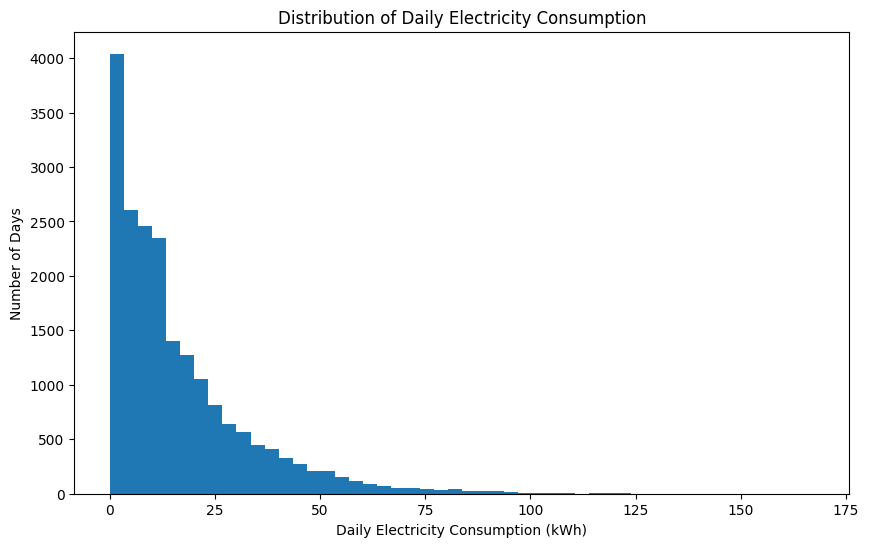

In [43]:
#EDA Step 1 — Target Distribution
import matplotlib.pyplot as plt

target = "Electricity_Consumption_kWh"

plt.figure(figsize=(10, 6))
plt.hist(master_df[target], bins=50)
plt.xlabel("Daily Electricity Consumption (kWh)")
plt.ylabel("Number of Days")
plt.title("Distribution of Daily Electricity Consumption")
plt.show()

In [45]:
#EDA Step 2 — Consumption by City
# Average consumption by city
city_consumption = (
    master_df.groupby("City")["Electricity_Consumption_kWh"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

print(city_consumption)

           count       mean     median  min         max
City                                                   
Lahore      3188  23.866868  19.279116  0.0  137.475332
Karachi     3632  21.527589  16.969307  0.0  137.020233
Multan      3616  17.330069  12.596410  0.0  167.470849
Peshawar    3490  14.627298  10.149046  0.0  100.852028
Islamabad   3468  12.990435   8.270190  0.0  102.178006
Skardu      2453   3.558248   1.946874  0.0   39.444409


<Figure size 1200x600 with 0 Axes>

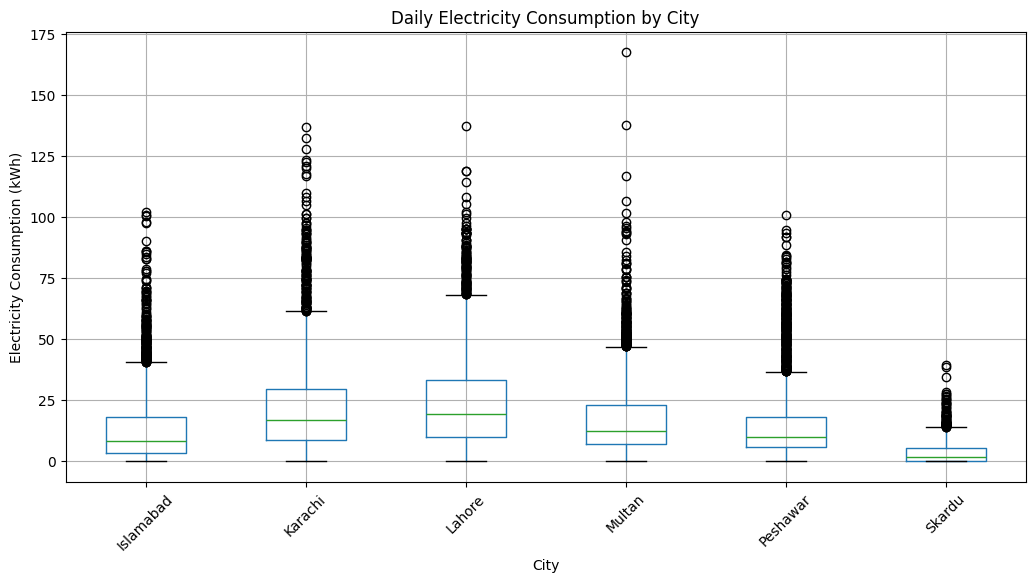

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

master_df.boxplot(
    column="Electricity_Consumption_kWh",
    by="City",
    figsize=(12, 6)
)

plt.title("Daily Electricity Consumption by City")
plt.suptitle("")
plt.xlabel("City")
plt.ylabel("Electricity Consumption (kWh)")
plt.xticks(rotation=45)
plt.show()

In [47]:
#EDA Step 3 — Monthly/Seasonal Consumption
# Create temporary time features for EDA
master_df["Year"] = master_df["date"].dt.year
master_df["Month"] = master_df["date"].dt.month
master_df["Month_Name"] = master_df["date"].dt.month_name()

monthly_consumption = (
    master_df.groupby(["Year", "Month"])["Electricity_Consumption_kWh"]
    .mean()
    .reset_index()
)

print(monthly_consumption)

    Year  Month  Electricity_Consumption_kWh
0   2023      7                     1.281283
1   2023      8                     2.951396
2   2023      9                     6.472562
3   2023     10                     8.344129
4   2023     11                     2.072695
5   2023     12                     9.221547
6   2024      1                    12.027375
7   2024      2                    10.183066
8   2024      3                    10.374078
9   2024      4                    13.123512
10  2024      5                    23.335362
11  2024      6                    28.895855
12  2024      7                    29.476676
13  2024      8                    23.332657
14  2024      9                    23.845299
15  2024     10                    17.928878
16  2024     11                     5.901952


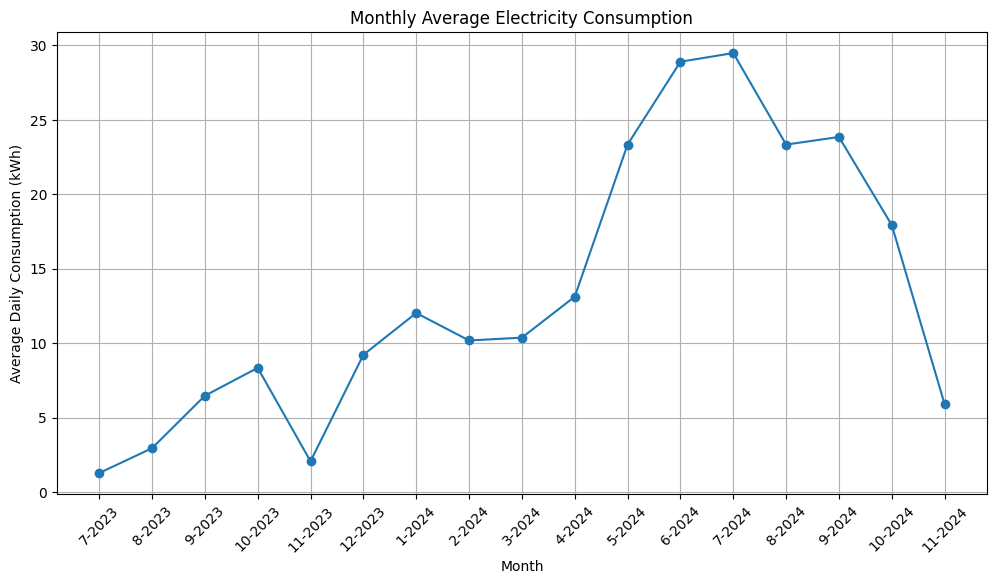

In [48]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_consumption["Month"].astype(str) + "-" +
    monthly_consumption["Year"].astype(str),
    monthly_consumption["Electricity_Consumption_kWh"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Daily Consumption (kWh)")
plt.title("Monthly Average Electricity Consumption")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [50]:
#EDA Step 4 — Consumption vs Temperature
correlation = master_df[
    ["Electricity_Consumption_kWh", "Temperature"]
].corr()

print(correlation)

                             Electricity_Consumption_kWh  Temperature
Electricity_Consumption_kWh                     1.000000     0.485672
Temperature                                     0.485672     1.000000


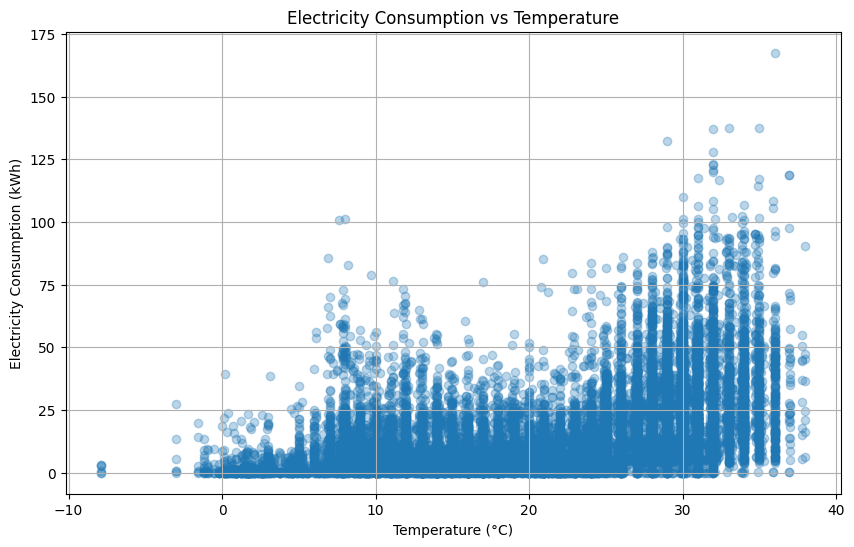

In [51]:
plt.figure(figsize=(10, 6))

plt.scatter(
    master_df["Temperature"],
    master_df["Electricity_Consumption_kWh"],
    alpha=0.3
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Electricity Consumption (kWh)")
plt.title("Electricity Consumption vs Temperature")
plt.grid(True)
plt.show()

In [53]:
#EDA Finding — Temperature vs Electricity Consumption
#EDA Step 5 — Appliance Relationships
ac_consumption = (
    master_df.groupby("Air_Conditioners")["Electricity_Consumption_kWh"]
    .agg(["count", "mean", "median"])
)

print(ac_consumption)

                  count       mean     median
Air_Conditioners                             
0.0                3168   8.743545   2.888479
1.0                2057  10.479614   8.052373
2.0                1803  13.494532  11.396186
3.0                4598  16.078408  12.323302
4.0                2881  14.510428  11.564416
5.0                2915  22.000001  16.658113
6.0                 984  28.691254  20.702761
7.0                 718  28.733314  26.910643
8.0                 358  23.728492  21.517563
12.0                365  30.034120  24.271711


In [54]:
#EDA Step 6 — Other Appliance Relationships
appliances = [
    "Air_Conditioners",
    "Air_Coolers",
    "Refrigerators",
    "Washing_Machines",
    "Ceiling_Fans",
    "Water_Pumps",
    "Electric_Heaters",
    "Geysers"
]

for appliance in appliances:
    result = (
        master_df.groupby(appliance)["Electricity_Consumption_kWh"]
        .mean()
    )

    print(f"\n{appliance}")
    print(result)


Air_Conditioners
Air_Conditioners
0.0      8.743545
1.0     10.479614
2.0     13.494532
3.0     16.078408
4.0     14.510428
5.0     22.000001
6.0     28.691254
7.0     28.733314
8.0     23.728492
12.0    30.034120
Name: Electricity_Consumption_kWh, dtype: float64

Air_Coolers
Air_Coolers
0    15.069705
1    19.362916
2    13.899620
Name: Electricity_Consumption_kWh, dtype: float64

Refrigerators
Refrigerators
0.0    27.870894
1.0    13.583811
2.0    20.427895
3.0    23.301649
Name: Electricity_Consumption_kWh, dtype: float64

Washing_Machines
Washing_Machines
1    16.297834
2    13.854369
Name: Electricity_Consumption_kWh, dtype: float64

Ceiling_Fans
Ceiling_Fans
0.0     15.627026
1.0      3.346273
2.0      4.951528
3.0     10.635144
4.0     18.788617
5.0     11.343520
6.0     14.548206
7.0     19.927675
8.0     14.545493
9.0     27.135842
10.0    19.588028
11.0    20.623075
13.0    13.292215
14.0    20.156600
16.0    25.650693
20.0    30.612233
Name: Electricity_Consumption_kWh, dty

In [55]:
#EDA Step 7 — Correlation Analysis
# Select numeric columns
numeric_df = master_df.select_dtypes(include="number")

# Calculate correlation with target
target_corr = (
    numeric_df.corr()["Electricity_Consumption_kWh"]
    .sort_values(ascending=False)
)

print(target_corr)

Electricity_Consumption_kWh    1.000000
Temperature                    0.485672
Dew                            0.433586
Air_Conditioners               0.330248
Year                           0.323285
Ceiling_Fans                   0.239002
No_of_Rooms                    0.237291
Property_Area_Marla            0.231511
Number_of_Washrooms            0.231354
Wind_Direction                 0.217423
Covered_Area                   0.206976
Water_Dispensers               0.201440
LED_Bulbs                      0.191561
Wind_Speed                     0.151828
Other_Electronic_Devices       0.150255
Refrigerators                  0.119086
Water_Pumps                    0.118579
Kitchen                        0.118451
Number_of_Stores               0.117310
Geysers                        0.100264
Seniors                        0.098082
Ceiling_Height_ft              0.087479
No_of_Floors                   0.078604
Electric_Heaters               0.070115
Stand_Fans                     0.066173


In [56]:
solar_cols = [
    "Solar_Radiation",
    "Solar_Energy",
    "UV_Index"
]

print(master_df[solar_cols].describe())

       Solar_Radiation  Solar_Energy  UV_Index
count          19847.0       19847.0   19847.0
mean               0.0           0.0       0.0
std                0.0           0.0       0.0
min                0.0           0.0       0.0
25%                0.0           0.0       0.0
50%                0.0           0.0       0.0
75%                0.0           0.0       0.0
max                0.0           0.0       0.0


In [57]:
print("\nNumber of unique values:")
print(master_df[solar_cols].nunique())

print("\nStandard deviation:")
print(master_df[solar_cols].std())


Number of unique values:
Solar_Radiation    1
Solar_Energy       1
UV_Index           1
dtype: int64

Standard deviation:
Solar_Radiation    0.0
Solar_Energy       0.0
UV_Index           0.0
dtype: float64


In [58]:
#EDA Step 8 — Check numerical feature variance
# Find zero-variance numeric features

numeric_cols = master_df.select_dtypes(include="number").columns

zero_variance_cols = [
    col for col in numeric_cols
    if master_df[col].nunique() <= 1
]

print("Zero-variance numeric columns:")
print(zero_variance_cols)

print("\nNumber of zero-variance columns:",
      len(zero_variance_cols))

Zero-variance numeric columns:
['Solar_Radiation', 'Solar_Energy', 'UV_Index']

Number of zero-variance columns: 3


In [59]:
#EDA Step 9 — Consumption by House
house_consumption = (
    master_df.groupby(["City", "House"])["Electricity_Consumption_kWh"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

print(house_consumption.to_string())

                    count       mean     median       min         max
City      House                                                      
Karachi   House#32    365  46.625663  43.934751  0.438667  137.020233
Lahore    House#6     365  40.809098  37.370181  0.000000  118.792108
          House#8     357  37.005838  38.225149  0.441583  137.475332
          House#2     365  30.612233  26.458385  0.566967   76.629453
Islamabad House#48    365  30.034120  24.271711  0.081500  102.178006
Peshawar  House#30    363  29.698788  21.099703  0.000000  100.852028
Multan    House#17    407  28.260237  21.231842  0.509200  167.470849
Karachi   House#31    365  26.631172  25.637745  0.200967   84.525412
          House#40    364  26.109620  27.181156  0.000000   77.761018
Multan    House#13    364  25.058358  14.726785  0.214383  106.628684
          House#16    358  23.728492  21.517563  0.043717   68.944973
Lahore    House#3     366  23.404856  13.794125  0.025293   92.813711
Karachi   House#34  

In [60]:
#EDA Step 10 — Consumption by Day of Week
# Create temporary day-of-week feature
master_df["Day_of_Week"] = master_df["date"].dt.day_name()

day_consumption = (
    master_df.groupby("Day_of_Week")["Electricity_Consumption_kWh"]
    .agg(["count", "mean", "median"])
)

# Put days in correct order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_consumption = day_consumption.reindex(day_order)

print(day_consumption)

             count       mean     median
Day_of_Week                             
Monday        2836  16.498223  11.242967
Tuesday       2826  16.444310  11.363039
Wednesday     2870  16.429339  11.235590
Thursday      2833  16.195381  11.219782
Friday        2825  15.900180  10.982087
Saturday      2825  15.784703  10.754134
Sunday        2832  16.230824  11.068460


In [61]:
# EDA Step 11: Household size vs electricity consumption

people_consumption = (
    master_df.groupby("Total_People")["Electricity_Consumption_kWh"]
    .agg(["count", "mean", "median"])
    .sort_index()
)

print(people_consumption)

              count       mean     median
Total_People                             
0.0             364  25.058358  14.726785
2.0             364   6.006749   5.752588
3.0             727   8.169771   5.700226
4.0            4704  13.615397  10.661706
5.0            3946  17.664097  13.000995
5.5             365  46.625663  43.934751
6.0            2900  18.899425  12.581927
7.0            2832  15.650788   9.640794
8.0            1434  19.340065  17.154980
9.0             700   6.667844   4.486518
10.0            496   4.951528   3.824343
11.0           1015  19.474359  11.580248


In [ ]:
correlation = master_df[
    ["Total_People", "Electricity_Consumption_kWh"]
].corr().iloc[0, 1]

print("Correlation between Total_People and Electricity Consumption:",
      correlation)

#Household population has almost no linear correlation with electricity consumption (r ≈ 0.011). Therefore, household size does not appear to be a major standalone driver of consumption in this dataset, although it may still contribute when combined with other features.

Correlation between Total_People and Electricity Consumption: 0.01066473010930971


In [ ]:
#EDA Step 12 — Property Area vs Electricity Consumption
# EDA Step 12: Property area vs electricity consumption

correlation = master_df[
    ["Property_Area_Marla", "Electricity_Consumption_kWh"]
].corr().iloc[0, 1]

print("Correlation between Property_Area_Marla and Electricity Consumption:",
      correlation)

#Property area has a positive correlation (r ≈ 0.232) with electricity consumption. Larger properties generally consume more electricity, although the relationship is relatively weak and other factors contribute substantially to electricity demand.

Correlation between Property_Area_Marla and Electricity Consumption: 0.23151109785505058


In [64]:
# EDA Step 13: Covered area vs electricity consumption

correlation = master_df[
    ["Covered_Area", "Electricity_Consumption_kWh"]
].corr().iloc[0, 1]

print("Correlation between Covered_Area and Electricity Consumption:",
      correlation)

Correlation between Covered_Area and Electricity Consumption: 0.20697608667120326


In [65]:
# EDA Step 14: Number of rooms vs electricity consumption

correlation = master_df[
    ["No_of_Rooms", "Electricity_Consumption_kWh"]
].corr().iloc[0, 1]

print("Correlation between No_of_Rooms and Electricity Consumption:",
      correlation)

Correlation between No_of_Rooms and Electricity Consumption: 0.237290672750105


In [66]:
# EDA Step 15: Air Conditioners vs electricity consumption

correlation = master_df[
    ["Air_Conditioners", "Electricity_Consumption_kWh"]
].corr().iloc[0, 1]

print("Correlation between Air_Conditioners and Electricity Consumption:",
      correlation)

Correlation between Air_Conditioners and Electricity Consumption: 0.3302480096854486


In [67]:
# EDA Step 16: Water Pumps vs electricity consumption

correlation = master_df[
    ["Water_Pumps", "Electricity_Consumption_kWh"]
].corr().iloc[0, 1]

print("Correlation between Water_Pumps and Electricity Consumption:",
      correlation)

Correlation between Water_Pumps and Electricity Consumption: 0.11857886741937546


In [68]:
# EDA Step 17: Geysers vs electricity consumption

correlation = master_df[
    ["Geysers", "Electricity_Consumption_kWh"]
].corr().iloc[0, 1]

print("Correlation between Geysers and Electricity Consumption:",
      correlation)

Correlation between Geysers and Electricity Consumption: 0.10026414140723625


In [69]:
# EDA Step 18: Ceiling Fans vs electricity consumption

correlation = master_df[
    ["Ceiling_Fans", "Electricity_Consumption_kWh"]
].corr().iloc[0, 1]

print("Correlation between Ceiling_Fans and Electricity Consumption:",
      correlation)

Correlation between Ceiling_Fans and Electricity Consumption: 0.239001972692173


In [70]:
# EDA Step 19: Refrigerators vs electricity consumption

correlation = master_df[
    ["Refrigerators", "Electricity_Consumption_kWh"]
].corr().iloc[0, 1]

print("Correlation between Refrigerators and Electricity Consumption:",
      correlation)

Correlation between Refrigerators and Electricity Consumption: 0.11908602463809745


In [71]:
# ============================================================
# EDA — Remaining Appliances vs Electricity Consumption
# ============================================================

target = "Electricity_Consumption_kWh"

remaining_appliances = [
    "Refrigerators",
    "Washing_Machines",
    "LED_Bulbs",
    "Tube_Lights",
    "Wall_Fans",
    "Stand_Fans",
    "Water_Dispensers",
    "Electric_Cooker",
    "Electric_Heaters",
    "Electric_Irons",
    "Sewing_Machine",
    "Microwave_Ovens",
    "UPS",
    "Other_Electronic_Devices"
]

print("=" * 65)
print("APPLIANCE CORRELATION WITH ELECTRICITY CONSUMPTION")
print("=" * 65)

for appliance in remaining_appliances:

    correlation = master_df[
        [appliance, target]
    ].corr().iloc[0, 1]

    print(
        f"Correlation between {appliance} and "
        f"Electricity Consumption: {correlation:.6f}"
    )

APPLIANCE CORRELATION WITH ELECTRICITY CONSUMPTION
Correlation between Refrigerators and Electricity Consumption: 0.119086
Correlation between Washing_Machines and Electricity Consumption: -0.026752
Correlation between LED_Bulbs and Electricity Consumption: 0.191561
Correlation between Tube_Lights and Electricity Consumption: 0.034295
Correlation between Wall_Fans and Electricity Consumption: 0.055843
Correlation between Stand_Fans and Electricity Consumption: 0.066173
Correlation between Water_Dispensers and Electricity Consumption: 0.201440
Correlation between Electric_Cooker and Electricity Consumption: 0.022047
Correlation between Electric_Heaters and Electricity Consumption: 0.070115
Correlation between Electric_Irons and Electricity Consumption: 0.035463
Correlation between Sewing_Machine and Electricity Consumption: -0.044206
Correlation between Microwave_Ovens and Electricity Consumption: 0.053290
Correlation between UPS and Electricity Consumption: -0.042038
Correlation betwee

In [72]:
# ============================================================
# EDA Step 19 — Owner/Rented vs Electricity Consumption
# ============================================================

owner_consumption = (
    master_df.groupby("Owner/Rented")["Electricity_Consumption_kWh"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

print("=" * 70)
print("ELECTRICITY CONSUMPTION BY OWNER/RENTED STATUS")
print("=" * 70)
print(owner_consumption)

ELECTRICITY CONSUMPTION BY OWNER/RENTED STATUS
                    count       mean     median  min         max
Owner/Rented                                                    
Residing As Tenant    364  26.109620  27.181156  0.0   77.761018
Owner               17338  16.467042  11.220406  0.0  167.470849
Rented               2145  12.475669   9.606059  0.0   57.853214


In [73]:
# ============================================================
# EDA Step 20 — WAPDA Connection Type
# ============================================================

wapda_consumption = (
    master_df.groupby("Wapda_Connection_Type")[
        "Electricity_Consumption_kWh"
    ]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

print("=" * 70)
print("ELECTRICITY CONSUMPTION BY WAPDA CONNECTION TYPE")
print("=" * 70)
print(wapda_consumption)

ELECTRICITY CONSUMPTION BY WAPDA CONNECTION TYPE
                       count       mean     median  min         max
Wapda_Connection_Type                                              
Net Meter               2492  24.822881  20.161210  0.0  137.475332
3 phase                 7894  19.395931  15.088903  0.0  167.470849
1 phase                 9461  11.288415   6.780762  0.0  137.020233


In [74]:
# ============================================================
# EDA Step 21 — Ceiling Type
# ============================================================

ceiling_consumption = (
    master_df.groupby("Ceiling_Type")[
        "Electricity_Consumption_kWh"
    ]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

print("=" * 70)
print("ELECTRICITY CONSUMPTION BY CEILING TYPE")
print("=" * 70)
print(ceiling_consumption)

ELECTRICITY CONSUMPTION BY CEILING TYPE
              count       mean     median     min         max
Ceiling_Type                                                 
Painted         407  28.260237  21.231842  0.5092  167.470849
Concrete       5943  17.418813  11.965101  0.0000  137.475332
Cemented       8590  15.331143  10.056792  0.0000  137.020233
Fall Ceiling   4907  15.295160  10.641671  0.0000  100.852028


In [75]:
# ============================================================
# EDA Step 22 — Roof Type
# ============================================================

roof_consumption = (
    master_df.groupby("Roof_Type")[
        "Electricity_Consumption_kWh"
    ]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

print("=" * 70)
print("ELECTRICITY CONSUMPTION BY ROOF TYPE")
print("=" * 70)
print(roof_consumption)

ELECTRICITY CONSUMPTION BY ROOF TYPE
                                    count       mean     median       min  \
Roof_Type                                                                   
Concrete + reflected paint in july    407  28.260237  21.231842  0.509200   
Solar Covered                        1093  24.049475  18.885339  0.000000   
solar Panel                           361  20.552452  19.913642  0.003127   
Cemented                            15470  16.504164  11.338835  0.000000   
Cemeted                              1055  13.751402  10.969445  0.039683   
Mud Plaster                          1461   4.609998   3.632973  0.000000   

                                           max  
Roof_Type                                       
Concrete + reflected paint in july  167.470849  
Solar Covered                       106.628684  
solar Panel                          53.104171  
Cemented                            137.475332  
Cemeted                              64.107570  
Mud

In [76]:
master_df["Roof_Type"] = master_df["Roof_Type"].replace({
    "Cemeted": "Cemented"
})

In [77]:
# ============================================================
# EDA Step 23 — Flooring Type
# ============================================================

flooring_consumption = (
    master_df.groupby("Flooring_Type")[
        "Electricity_Consumption_kWh"
    ]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

print("=" * 70)
print("ELECTRICITY CONSUMPTION BY FLOORING TYPE")
print("=" * 70)
print(flooring_consumption)

ELECTRICITY CONSUMPTION BY FLOORING TYPE
               count       mean     median       min         max
Flooring_Type                                                   
chips            407  28.260237  21.231842  0.509200  167.470849
marble         10146  18.655671  12.537353  0.000000  137.475332
tiles           6129  15.798371  11.579857  0.000000  106.628684
painted          360  13.454434   9.830594  0.000509   51.572773
concrete        1420  10.947972   8.980488  0.000000   53.265044
cemented        1385   2.721657   1.328305  0.000000   23.001620


In [78]:
# ============================================================
# EDA Step 24 — Kitchen vs Electricity Consumption
# ============================================================

kitchen_consumption = (
    master_df.groupby("Kitchen")[
        "Electricity_Consumption_kWh"
    ]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

print("=" * 70)
print("ELECTRICITY CONSUMPTION BY KITCHEN")
print("=" * 70)
print(kitchen_consumption)

ELECTRICITY CONSUMPTION BY KITCHEN
         count       mean     median       min         max
Kitchen                                                   
2.0       3203  20.739782  16.617266  0.003127  137.475332
1.0      16644  15.341280  10.373055  0.000000  167.470849


In [79]:
# ============================================================
# EDA Step 25 — Number of Floors vs Electricity Consumption
# ============================================================

floors_consumption = (
    master_df.groupby("No_of_Floors")[
        "Electricity_Consumption_kWh"
    ]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

print("=" * 70)
print("ELECTRICITY CONSUMPTION BY NUMBER OF FLOORS")
print("=" * 70)
print(floors_consumption)

ELECTRICITY CONSUMPTION BY NUMBER OF FLOORS
              count       mean     median       min         max
No_of_Floors                                                   
5               365  30.612233  26.458385  0.566967   76.629453
4               727  20.746746  20.469841  0.077300   56.225291
15              365  19.608745  19.127081  0.017983   51.305386
2             11505  18.225827  11.707875  0.000000  137.475332
3              2435  11.871077   9.411417  0.000000   74.113835
1              4450  11.182480   8.204613  0.000000  167.470849


In [80]:
# ============================================================
# EDA Step 26 — Low-Frequency Category Check
# ============================================================

categorical_features = [
    "City",
    "Owner/Rented",
    "Wapda_Connection_Type",
    "Ceiling_Type",
    "Roof_Type",
    "Flooring_Type",
    "Interior_Wall",
    "Exterior_Wall",
    "Room_Dimensions",
    "Kitchen",
    "Doors_Type"
]

print("=" * 80)
print("LOW-FREQUENCY CATEGORY CHECK — HOUSEHOLD LEVEL")
print("=" * 80)

# Keep one record per house so daily repetition does not inflate counts
household_df = master_df.drop_duplicates(subset="House").copy()

for feature in categorical_features:

    print("\n" + "-" * 80)
    print(f"{feature}")
    print("-" * 80)

    category_counts = (
        household_df[feature]
        .value_counts(dropna=False)
        .sort_values()
    )

    print(category_counts)

LOW-FREQUENCY CATEGORY CHECK — HOUSEHOLD LEVEL

--------------------------------------------------------------------------------
City
--------------------------------------------------------------------------------
City
Skardu        7
Lahore        9
Multan       10
Peshawar     10
Karachi      10
Islamabad    10
Name: count, dtype: int64

--------------------------------------------------------------------------------
Owner/Rented
--------------------------------------------------------------------------------
Owner/Rented
Residing As Tenant     1
Rented                 6
Owner                 49
Name: count, dtype: int64

--------------------------------------------------------------------------------
Wapda_Connection_Type
--------------------------------------------------------------------------------
Wapda_Connection_Type
Net Meter     7
3 phase      22
1 phase      27
Name: count, dtype: int64

--------------------------------------------------------------------------------
Ceili

In [4]:
# ============================================================
# EDA Step 27 — Outlier Check for Target and Major Features
# ============================================================

numeric_features = [
    "Electricity_Consumption_kWh",
    "Temperature",
    "Dew",
    "Air_Conditioners",
    "Ceiling_Fans",
    "No_of_Rooms",
    "Property_Area_Marla",
    "Covered_Area",
    "Number_of_Washrooms",
    "Water_Dispensers",
    "Water_Pumps",
    "Geysers",
    "Other_Electronic_Devices"
]

print("=" * 85)
print("OUTLIER CHECK — IQR METHOD")
print("=" * 85)

for feature in numeric_features:

    Q1 = master_df[feature].quantile(0.25)
    Q3 = master_df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = master_df[
        (master_df[feature] < lower_bound) |
        (master_df[feature] > upper_bound)
    ]

    print(f"\n{feature}")
    print(f"Q1: {Q1:.4f}")
    print(f"Q3: {Q3:.4f}")
    print(f"IQR: {IQR:.4f}")
    print(f"Lower Bound: {lower_bound:.4f}")
    print(f"Upper Bound: {upper_bound:.4f}")
    print(f"Outliers: {len(outliers)}")
    print(f"Outlier %: {(len(outliers) / len(master_df) * 100):.2f}%")

OUTLIER CHECK — IQR METHOD

Electricity_Consumption_kWh
Q1: 4.7349
Q3: 22.4131
IQR: 17.6782
Lower Bound: -21.7824
Upper Bound: 48.9304
Outliers: 1081
Outlier %: 5.45%

Temperature
Q1: 14.2000
Q3: 29.0000
IQR: 14.8000
Lower Bound: -8.0000
Upper Bound: 51.2000
Outliers: 0
Outlier %: 0.00%

Dew
Q1: 8.0000
Q3: 22.0000
IQR: 14.0000
Lower Bound: -13.0000
Upper Bound: 43.0000
Outliers: 12
Outlier %: 0.06%

Air_Conditioners
Q1: 1.0000
Q3: 5.0000
IQR: 4.0000
Lower Bound: -5.0000
Upper Bound: 11.0000
Outliers: 365
Outlier %: 1.84%

Ceiling_Fans
Q1: 4.0000
Q3: 10.0000
IQR: 6.0000
Lower Bound: -5.0000
Upper Bound: 19.0000
Outliers: 365
Outlier %: 1.84%

No_of_Rooms
Q1: 4.0000
Q3: 6.0000
IQR: 2.0000
Lower Bound: 1.0000
Upper Bound: 9.0000
Outliers: 1448
Outlier %: 7.30%

Property_Area_Marla
Q1: 7.0000
Q3: 20.0000
IQR: 13.0000
Lower Bound: -12.5000
Upper Bound: 39.5000
Outliers: 2590
Outlier %: 13.05%

Covered_Area
Q1: 5.0000
Q3: 12.0000
IQR: 7.0000
Lower Bound: -5.5000
Upper Bound: 22.5000
Outliers

In [5]:
# ============================================================
# EDA Step 28 — Highest Consuming Houses
# ============================================================

house_consumption = (
    master_df.groupby(["City", "House"])["Electricity_Consumption_kWh"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

print("=" * 90)
print("TOP 10 HIGHEST-CONSUMING HOUSES")
print("=" * 90)

print(house_consumption.head(10))

TOP 10 HIGHEST-CONSUMING HOUSES
                    count       mean     median         max
City      House                                            
Karachi   House#32    365  46.625663  43.934751  137.020233
Lahore    House#6     365  40.809098  37.370181  118.792108
          House#8     357  37.005838  38.225149  137.475332
          House#2     365  30.612233  26.458385   76.629453
Islamabad House#48    365  30.034120  24.271711  102.178006
Peshawar  House#30    363  29.698788  21.099703  100.852028
Multan    House#17    407  28.260237  21.231842  167.470849
Karachi   House#31    365  26.631172  25.637745   84.525412
          House#40    364  26.109620  27.181156   77.761018
Multan    House#13    364  25.058358  14.726785  106.628684
